### Audit Risk Scoring Using Machine Learning Models

**Prepared By: Olumide Johnson Ikumapayi**

### Project Description

This project focused on developing an **audit risk scoring model** using **machine learning** to support fraud detection and risk classification in organizations. The model analyzes historical and current financial, operational, and organizational attributes to predict whether an entity should be classified as high-risk or low-risk. By transforming audit-related data into a predictive classification framework, the project helps auditors identify organizations that may require closer review, thereby **improving risk-based audit planning, strengthening fraud detection, and supporting more efficient allocation of audit resources**.

**Project Objective**

The objective of this project was to build a **Machine learning (ML) classification model** capable of assessing audit risk using relevant financial and organizational indicators. The model was designed to distinguish between **fraudulent or high-risk entities and non-fraudulent or low-risk entities** based on patterns in the data. The broader aim was to provide a data-driven decision support tool that can improve the accuracy of audit risk assessment, enhance early detection of suspicious cases, and assist auditors in prioritizing high-risk engagements more effectively.

**Motivation**

The motivation for this project was the need to improve the accuracy and efficiency of **audit risk assessment**. Traditional audit review processes can be time-consuming and may not always detect high-risk or potentially fraudulent entities early enough. By applying machine learning to audit-related data, the project aimed to support auditors with a more systematic and data-driven approach to identifying organizations that require closer investigation.

**Description of Dataset and Source**

The project used the **Audit Risk Dataset**, a publicly available dataset which contains historical and present financial and organizational attributes relevant to audit evaluation designed to support classification of fraudulent or high-risk firms.The dataset is commonly used for fraud detection and audit risk classification tasks and includes approximately 776 records and 27 features. These features capture multiple dimensions of audit-related risk, making the dataset suitable for supervised machine learning analysis.The dataset is available on the UCI Machine Learning Repository (Audit Data) and also in Kaggle mirror form as Audit Data, https://www.kaggle.com/datasets/sid321axn/audit-data


**Problem Type**

This project is a binary classification problem. The target variable represents audit risk status, where each organization is classified as either:

* 1 = High-risk / Fraudulent

* 0 = Low-risk / Non-fraudulent

The purpose of the model is to learn patterns from the input variables and accurately predict the risk category of each entity.

The flow of the **Audit Risk Scoring** dataset is as follows:

1. [Importing the Libraries](#Importing-the-Libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Data Description](#Data-Description)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Balancing the Dataset](#Balancing-the-Dataset)
9. [Machine Learning Models](#Machine-Learning-Models)
10.[Summary and Conclusion](#Summary-and-Conclusion)

### Importing the Libraries

In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import boxcox, zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import datasets, metrics, model_selection

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, SMOTENC

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    plot_roc_curve
)

# Model Persistence
import joblib

### Data Acquisition & Initial Inspection

#### Loading the dataset

In [2]:
df_auditRisk_data = pd.read_csv('audit_data.csv')
df_auditRisk_data.head()

,Sector_score,LOCATION_ID,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
0,3.89,23,4.18,0.6,2.508,2.50,0.2,0.500,6.68,5.0,...,0.4,0,0.2,0.0,2.4,8.574,0.4,0.5,1.7148,1
1,3.89,6,0.00,0.2,0.000,4.83,0.2,0.966,4.83,5.0,...,0.4,0,0.2,0.0,2.0,2.554,0.4,0.5,0.5108,0
2,3.89,6,0.51,0.2,0.102,0.23,0.2,0.046,0.74,5.0,...,0.4,0,0.2,0.0,2.0,1.548,0.4,0.5,0.3096,0
3,3.89,6,0.00,0.2,0.000,10.80,0.6,6.480,10.80,6.0,...,0.4,0,0.2,0.0,4.4,17.530,0.4,0.5,3.5060,1
4,3.89,6,0.00,0.2,0.000,0.08,0.2,0.016,0.08,5.0,...,0.4,0,0.2,0.0,2.0,1.416,0.4,0.5,0.2832,0


In [3]:
df_auditRisk_data.tail()

,Sector_score,LOCATION_ID,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
771,55.57,9,0.49,0.2,0.098,0.40,0.2,0.080,0.89,5.0,...,0.4,0,0.2,0.0,2.0,1.578,0.4,0.5,0.3156,0
772,55.57,16,0.47,0.2,0.094,0.37,0.2,0.074,0.84,5.0,...,0.4,0,0.2,0.0,2.0,1.568,0.4,0.5,0.3136,0
773,55.57,14,0.24,0.2,0.048,0.04,0.2,0.008,0.28,5.0,...,0.4,0,0.2,0.0,2.0,1.456,0.4,0.5,0.2912,0
774,55.57,18,0.20,0.2,0.040,0.00,0.2,0.000,0.20,5.0,...,0.4,0,0.2,0.0,2.0,1.440,0.4,0.5,0.2880,0
775,55.57,15,0.00,0.2,0.000,0.00,0.2,0.000,0.00,5.0,...,0.4,0,0.2,0.0,2.0,1.464,0.4,0.5,0.2928,0


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_auditRisk_data.shape

(776, 27)

The dataset contains 776 rows and 27 columns.Of which 1 is target variable and the remaining 26 are independent varbiables.

In [5]:
# Check column of the dataset
df_auditRisk_data.columns

Index(['Sector_score', 'LOCATION_ID', 'PARA_A', 'Score_A', 'Risk_A', 'PARA_B',
       'Score_B', 'Risk_B', 'TOTAL', 'numbers', 'Score_B.1', 'Risk_C',
       'Money_Value', 'Score_MV', 'Risk_D', 'District_Loss', 'PROB', 'RiSk_E',
       'History', 'Prob', 'Risk_F', 'Score', 'Inherent_Risk', 'CONTROL_RISK',
       'Detection_Risk', 'Audit_Risk', 'Risk'],
      dtype='object')

In [6]:
# Checking the list of columns for dataset
df_auditRisk_data.columns.tolist()

['Sector_score',
 'LOCATION_ID',
 'PARA_A',
 'Score_A',
 'Risk_A',
 'PARA_B',
 'Score_B',
 'Risk_B',
 'TOTAL',
 'numbers',
 'Score_B.1',
 'Risk_C',
 'Money_Value',
 'Score_MV',
 'Risk_D',
 'District_Loss',
 'PROB',
 'RiSk_E',
 'History',
 'Prob',
 'Risk_F',
 'Score',
 'Inherent_Risk',
 'CONTROL_RISK',
 'Detection_Risk',
 'Audit_Risk',
 'Risk']

In [7]:
# checking the types of columns
df_auditRisk_data.dtypes

Sector_score      float64
LOCATION_ID        object
PARA_A            float64
Score_A           float64
Risk_A            float64
PARA_B            float64
Score_B           float64
Risk_B            float64
TOTAL             float64
numbers           float64
Score_B.1         float64
Risk_C            float64
Money_Value       float64
Score_MV          float64
Risk_D            float64
District_Loss       int64
PROB              float64
RiSk_E            float64
History             int64
Prob              float64
Risk_F            float64
Score             float64
Inherent_Risk     float64
CONTROL_RISK      float64
Detection_Risk    float64
Audit_Risk        float64
Risk                int64
dtype: object

There three(3) different types of data present in the dataset i.e.float64, object and int64. 

In [8]:
# Checking the column info
df_auditRisk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sector_score    776 non-null    float64
 1   LOCATION_ID     776 non-null    object 
 2   PARA_A          776 non-null    float64
 3   Score_A         776 non-null    float64
 4   Risk_A          776 non-null    float64
 5   PARA_B          776 non-null    float64
 6   Score_B         776 non-null    float64
 7   Risk_B          776 non-null    float64
 8   TOTAL           776 non-null    float64
 9   numbers         776 non-null    float64
 10  Score_B.1       776 non-null    float64
 11  Risk_C          776 non-null    float64
 12  Money_Value     775 non-null    float64
 13  Score_MV        776 non-null    float64
 14  Risk_D          776 non-null    float64
 15  District_Loss   776 non-null    int64  
 16  PROB            776 non-null    float64
 17  RiSk_E          776 non-null    flo

This are some of the features of the dataset,which contains **776 records and 27 variables**, with a mix of **numerical** and **categorical** data types. Most of the features are numerical risk-related indicators, while **'LOCATION_ID'** is the only categorical variable, and the target variable **'Risk'** is an integer. There is only one missing value in the dataset which is in the **'Money_Value'** feature, hence the need for a minimal data cleaning before modeling.


This are some of the features of the dataset,which includes indexing type,column type,non null values and memory usage.As shown, there are few missing values in the dataset which we must handle.

### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [9]:
# checking null values
df_auditRisk_data.isnull().sum()

Sector_score      0
LOCATION_ID       0
PARA_A            0
Score_A           0
Risk_A            0
PARA_B            0
Score_B           0
Risk_B            0
TOTAL             0
numbers           0
Score_B.1         0
Risk_C            0
Money_Value       1
Score_MV          0
Risk_D            0
District_Loss     0
PROB              0
RiSk_E            0
History           0
Prob              0
Risk_F            0
Score             0
Inherent_Risk     0
CONTROL_RISK      0
Detection_Risk    0
Audit_Risk        0
Risk              0
dtype: int64

The **Money Value** column has null/missing values.

In [10]:
# The total Number of missing values in the dataset
df_auditRisk_data.isnull().sum().sum()

1

**Treating the Missing Values**

In [11]:
# Confirming column exists
print('Money_Value' in df_auditRisk_data.columns)

True


In [12]:
# How many missing values?
print(df_auditRisk_data['Money_Value'].isna().sum())

1


In [13]:
# What does mode() return?
print(df_auditRisk_data['Money_Value'].mode())

0    0.0
Name: Money_Value, dtype: float64


In [14]:
# Lets fill the missing values
df_auditRisk_data['Money_Value'] = df_auditRisk_data['Money_Value'].fillna(df_auditRisk_data['Money_Value'].mode()[0])

In [15]:
# Check again the null values
df_auditRisk_data.isnull().sum()

Sector_score      0
LOCATION_ID       0
PARA_A            0
Score_A           0
Risk_A            0
PARA_B            0
Score_B           0
Risk_B            0
TOTAL             0
numbers           0
Score_B.1         0
Risk_C            0
Money_Value       0
Score_MV          0
Risk_D            0
District_Loss     0
PROB              0
RiSk_E            0
History           0
Prob              0
Risk_F            0
Score             0
Inherent_Risk     0
CONTROL_RISK      0
Detection_Risk    0
Audit_Risk        0
Risk              0
dtype: int64

The null/missing values has now been treated.

In [16]:
# Let's have a better overview of the dataset
df_auditRisk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sector_score    776 non-null    float64
 1   LOCATION_ID     776 non-null    object 
 2   PARA_A          776 non-null    float64
 3   Score_A         776 non-null    float64
 4   Risk_A          776 non-null    float64
 5   PARA_B          776 non-null    float64
 6   Score_B         776 non-null    float64
 7   Risk_B          776 non-null    float64
 8   TOTAL           776 non-null    float64
 9   numbers         776 non-null    float64
 10  Score_B.1       776 non-null    float64
 11  Risk_C          776 non-null    float64
 12  Money_Value     776 non-null    float64
 13  Score_MV        776 non-null    float64
 14  Risk_D          776 non-null    float64
 15  District_Loss   776 non-null    int64  
 16  PROB            776 non-null    float64
 17  RiSk_E          776 non-null    flo

There is no more missing value in the DataSet, all 776 complete.

<AxesSubplot:>

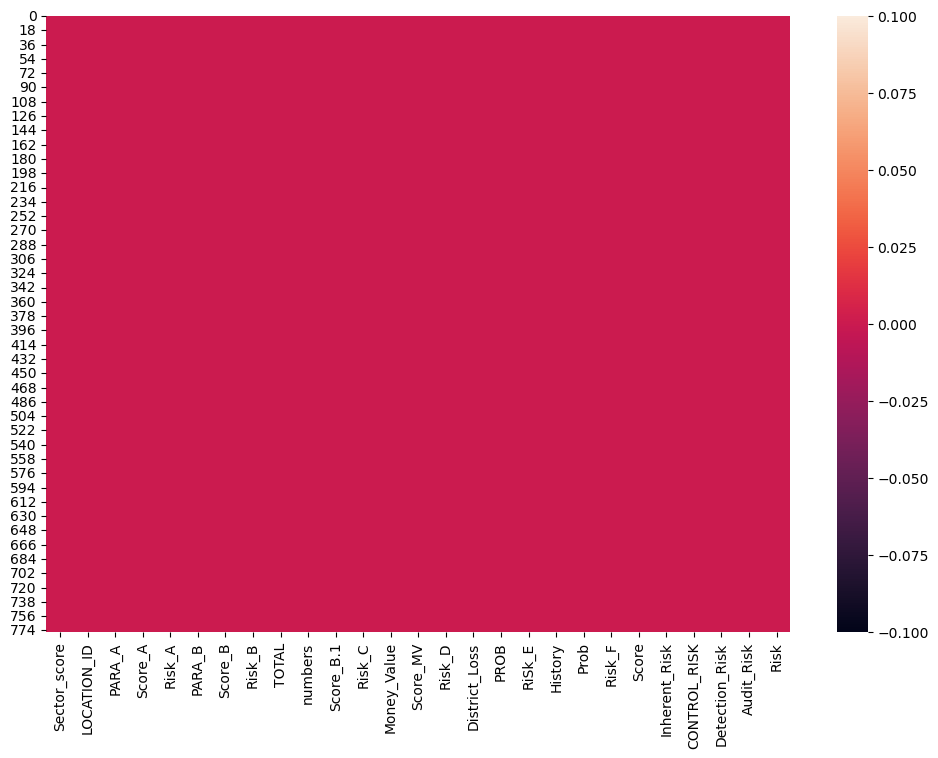

In [17]:
# Let's Visualize using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_auditRisk_data.isnull())

The above heatmap clearly indicates that the dataset is almost entirely complete, with no widespread missing-data problem across the variables.

In [18]:
# Checking the unique values of objects-column
for col in df_auditRisk_data.select_dtypes(include='object').columns:
    print(col)
    print(df_auditRisk_data[col].unique())

LOCATION_ID
['23' '6' '7' '8' '13' '37' '24' '3' '4' '14' '5' '20' '19' '21' '22' '9'
 '11' '12' '29' '30' '38' '31' '2' '32' '16' '33' '15' '36' '34' '18' '25'
 '39' '27' '35' '40' '41' '42' '1' '28' 'LOHARU' 'NUH' 'SAFIDON' '43' '44'
 '17']


In [19]:
# Finding number of unique values in the column
df_auditRisk_data.nunique().to_frame("No.of unique values")

,No.of unique values
Sector_score,13
LOCATION_ID,45
PARA_A,363
Score_A,3
Risk_A,363
PARA_B,358
Score_B,3
Risk_B,360
TOTAL,471
numbers,5


All the features have more than one single values except for **Detection Risk**.

In [20]:
# Lets take a look at the 1st few heads again
df_auditRisk_data.head()

,Sector_score,LOCATION_ID,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
0,3.89,23,4.18,0.6,2.508,2.50,0.2,0.500,6.68,5.0,...,0.4,0,0.2,0.0,2.4,8.574,0.4,0.5,1.7148,1
1,3.89,6,0.00,0.2,0.000,4.83,0.2,0.966,4.83,5.0,...,0.4,0,0.2,0.0,2.0,2.554,0.4,0.5,0.5108,0
2,3.89,6,0.51,0.2,0.102,0.23,0.2,0.046,0.74,5.0,...,0.4,0,0.2,0.0,2.0,1.548,0.4,0.5,0.3096,0
3,3.89,6,0.00,0.2,0.000,10.80,0.6,6.480,10.80,6.0,...,0.4,0,0.2,0.0,4.4,17.530,0.4,0.5,3.5060,1
4,3.89,6,0.00,0.2,0.000,0.08,0.2,0.016,0.08,5.0,...,0.4,0,0.2,0.0,2.0,1.416,0.4,0.5,0.2832,0


In [21]:
# Checking the list of counts of target
df_auditRisk_data["Risk"].unique()

array([1, 0], dtype=int64)

There are two categories present in the target column namely **"1" and "0"**

In [22]:
# Checking the unique values in target column
df_auditRisk_data['Risk'].value_counts()

0    471
1    305
Name: Risk, dtype: int64

We hereby assume that "1" stands for **Fraudulent(high risk)** and "0" for **Non-Fraudulent/Legitimate(low risk)**.

### Data Description 

In [23]:
# Statistical summary of numerical columns
df_auditRisk_data.describe()

,Sector_score,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,Score_B.1,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
count,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,...,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.0,776.000000,776.000000
mean,20.184536,2.450194,0.351289,1.351029,10.799988,0.313144,6.334008,13.218481,5.067655,0.223711,...,0.519072,0.104381,0.216753,0.053608,2.702577,17.680612,0.572680,0.5,7.168158,0.393041
std,24.319017,5.678870,0.174055,3.440447,50.083624,0.169804,30.072845,51.312829,0.264449,0.080352,...,0.290312,0.531031,0.067987,0.305835,0.858923,54.740244,0.444581,0.0,38.667494,0.488741
min,1.850000,0.000000,0.200000,0.000000,0.000000,0.200000,0.000000,0.000000,5.000000,0.200000,...,0.400000,0.000000,0.200000,0.000000,2.000000,1.400000,0.400000,0.5,0.280000,0.000000
25%,2.370000,0.210000,0.200000,0.042000,0.000000,0.200000,0.000000,0.537500,5.000000,0.200000,...,0.400000,0.000000,0.200000,0.000000,2.000000,1.583500,0.400000,0.5,0.316700,0.000000
50%,3.890000,0.875000,0.200000,0.175000,0.405000,0.200000,0.081000,1.370000,5.000000,0.200000,...,0.400000,0.000000,0.200000,0.000000,2.400000,2.214000,0.400000,0.5,0.555600,0.000000
75%,55.570000,2.480000,0.600000,1.488000,4.160000,0.400000,1.840500,7.707500,5.000000,0.200000,...,0.400000,0.000000,0.200000,0.000000,3.250000,10.663500,0.400000,0.5,3.249900,1.000000
max,59.850000,85.000000,0.600000,51.000000,1264.630000,0.600000,758.778000,1268.910000,9.000000,0.600000,...,2.400000,9.000000,0.600000,5.400000,5.200000,801.262000,5.800000,0.5,961.514400,1.000000


These are the statistical details of the numerical columns.The dataset summary looks a bit better.

From the above we can analyse further-:

* The counts of all the columns are of same values,meaning there are no missing values in the dataset.
* The mean value is greater than the median(50%) in all the columns, an indication that the data is skewed to right in these columns.
* The datas in the columns with a less mean value to the median,implied that this data is skewed to the left.
* In Summary, we observed that there were huge differences between 75% and max,except for **Score_A** meaning there are outliers present in the dataset.
* We also notice the Standard deviation,min,25% percentile from this describe method.

In [24]:
# Lets also check the statistical distribution for numerical features
df_auditRisk_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sector_score,776.0,20.184536,24.319017,1.85,2.3700,3.8900,55.5700,59.8500
PARA_A,776.0,2.450194,5.678870,0.00,0.2100,0.8750,2.4800,85.0000
Score_A,776.0,0.351289,0.174055,0.20,0.2000,0.2000,0.6000,0.6000
Risk_A,776.0,1.351029,3.440447,0.00,0.0420,0.1750,1.4880,51.0000
PARA_B,776.0,10.799988,50.083624,0.00,0.0000,0.4050,4.1600,1264.6300
Score_B,776.0,0.313144,0.169804,0.20,0.2000,0.2000,0.4000,0.6000
Risk_B,776.0,6.334008,30.072845,0.00,0.0000,0.0810,1.8405,758.7780
TOTAL,776.0,13.218481,51.312829,0.00,0.5375,1.3700,7.7075,1268.9100
numbers,776.0,5.067655,0.264449,5.00,5.0000,5.0000,5.0000,9.0000
Score_B.1,776.0,0.223711,0.080352,0.20,0.2000,0.2000,0.2000,0.6000


### Exploratory Data Analysis (EDA)

**Univariate Analysis**

In [25]:
# The number of risk
print(df_auditRisk_data['Risk'].value_counts())

0    471
1    305
Name: Risk, dtype: int64


In [26]:
# The % rate of Risk
target_df=df_auditRisk_data['Risk'].value_counts()*100/df_auditRisk_data.shape[0]
target_df

0    60.695876
1    39.304124
Name: Risk, dtype: float64

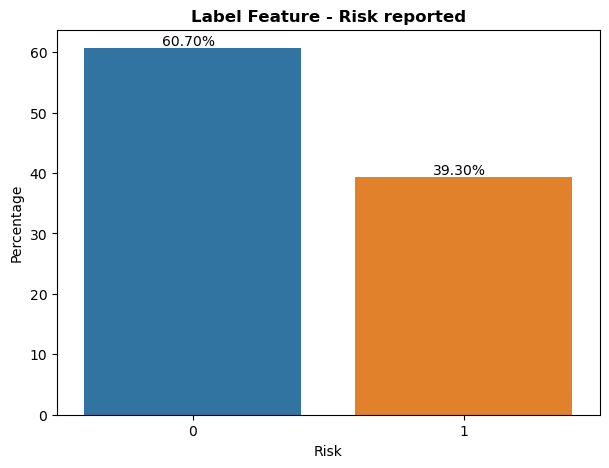

In [27]:
plt.figure(figsize=(7,5))
plt.title("Label Feature - Risk reported",fontdict={'fontweight':'bold','fontsize':12})
ax=sns.barplot(x=target_df.index,y=target_df.values)
plt.xlabel('Risk')
plt.ylabel('Percentage')

for p in ax.patches:
    height=p.get_height()
    width=p.get_width()
    x,_=p.get_xy()
    ax.text(x+width/2.8,height+0.5,f'{height:.2f}%')

The target distribution shows that **Risk = 0** represents **60.7%** of the observations, while **Risk = 1** accounts for **39.3%**. This indicates that the dataset is moderately imbalanced, but not severely skewed, hence both classes are still well represented for our model training and evaluation.


In [28]:
# Lets Separate the numerical from categorical columns

# checking out the categorical columns
categorical_col = []
for i in df_auditRisk_data.dtypes.index:
    if df_auditRisk_data.dtypes[i] == "object":
        categorical_col.append(i)
print("categorical columns:", categorical_col)
print("\n")

# Checking for Numerical column
numerical_col = []
for i in df_auditRisk_data.dtypes.index:
    if df_auditRisk_data.dtypes[i]!= "object":
        numerical_col.append(i)
print("numerical columns:", numerical_col)

categorical columns: ['LOCATION_ID']


numerical columns: ['Sector_score', 'PARA_A', 'Score_A', 'Risk_A', 'PARA_B', 'Score_B', 'Risk_B', 'TOTAL', 'numbers', 'Score_B.1', 'Risk_C', 'Money_Value', 'Score_MV', 'Risk_D', 'District_Loss', 'PROB', 'RiSk_E', 'History', 'Prob', 'Risk_F', 'Score', 'Inherent_Risk', 'CONTROL_RISK', 'Detection_Risk', 'Audit_Risk', 'Risk']


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, '55.57'),
  Text(1, 0, '3.89'),
  Text(2, 0, '1.85'),
  Text(3, 0, '2.72'),
  Text(4, 0, '3.41'),
  Text(5, 0, '2.37'),
  Text(6, 0, '1.99'),
  Text(7, 0, '21.61'),
  Text(8, 0, '59.85'),
  Text(9, 0, '2.34'),
  Text(10, 0, '15.56'),
  Text(11, 0, '2.36'),
  Text(12, 0, '17.68')])

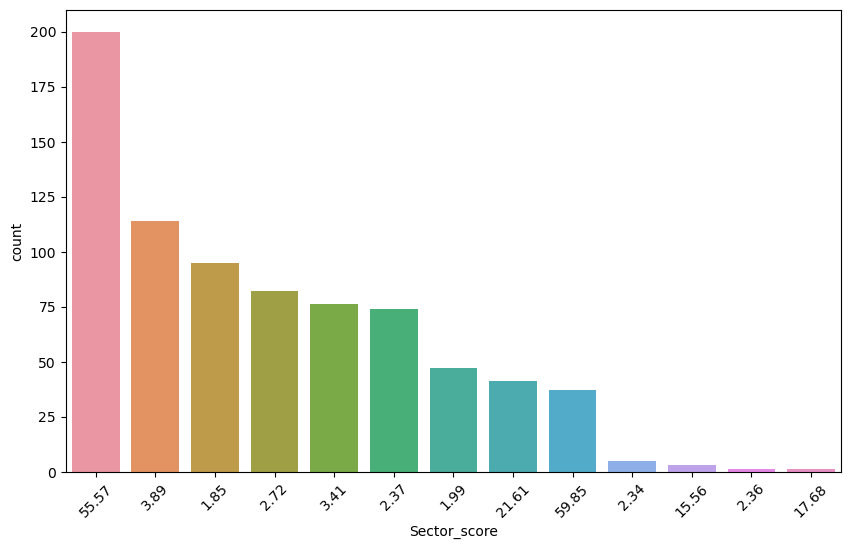

In [29]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Sector_score'],order=df_auditRisk_data['Sector_score'].value_counts().index)
plt.xticks(rotation=45)

The bar chart shows that **Sector_score **55.57** with **about 200 records** has the highest frequency in the dataset by a wide margin, followed by **3.89** with **about 115 records** and **1.85** with **about 95 records**. Most of the remaining sector scores occur much less often, while Other values such as **2.72**, **3.41**, and **2.37** appear at moderate levels, while **2.34**, **15.56**, **2.36**, and **17.68** occur only rarely. This suggests that the sector score distribution is uneven, with transactions concentrated in a small number of sector categories.


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '5.0'),
  Text(1, 0, '5.5'),
  Text(2, 0, '6.0'),
  Text(3, 0, '6.5'),
  Text(4, 0, '9.0')])

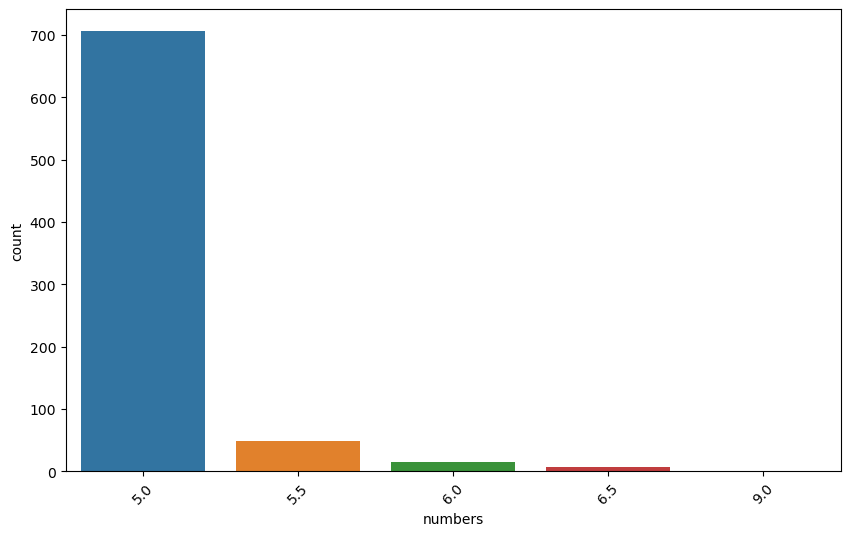

In [30]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['numbers'],order=df_auditRisk_data['numbers'].value_counts().index)
plt.xticks(rotation=45)

**numbers** is heavily dominated by **5.0** with **about 705 records**, followed by **5.5** with **about 50 records**, **6.0** with **about 15 records**, and **6.5** with **about 5 records**, while **9.0** rarely appeared. This indicates that the feature is highly concentrated around a single value.


(array([0, 1, 2]), [Text(0, 0, '0.2'), Text(1, 0, '0.6'), Text(2, 0, '0.4')])

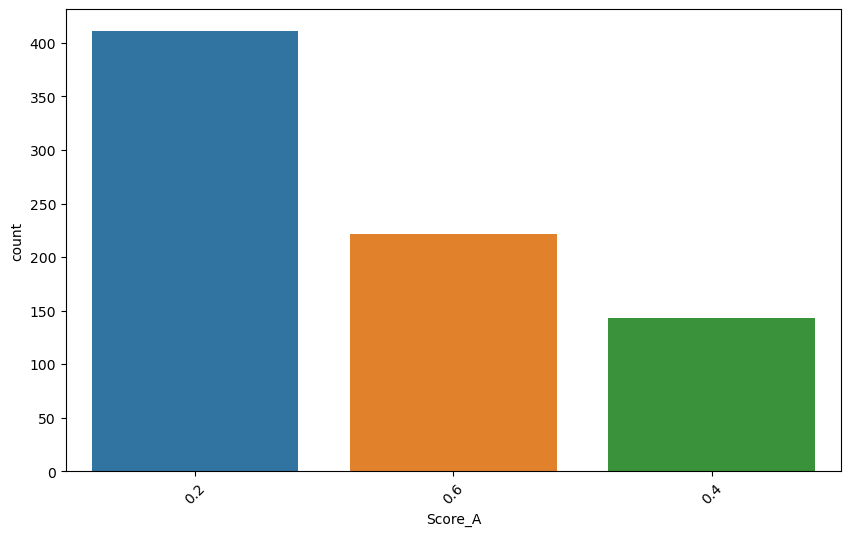

In [31]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Score_A'],order=df_auditRisk_data['Score_A'].value_counts().index)
plt.xticks(rotation=45)

The above chart shows that **Score_A** is most frequently concentrated at **0.2** with **about 410 records**, followed by  **0.6** with **about 220 records**, while **0.4** has **about 145 records** appearing less often. This suggests that the feature takes only a few discrete values and is unevenly distributed across them. Hence,the lower **Score_A** values dominates the dataset with its frequency of occurrence.


(array([0, 1, 2]), [Text(0, 0, '0.2'), Text(1, 0, '0.6'), Text(2, 0, '0.4')])

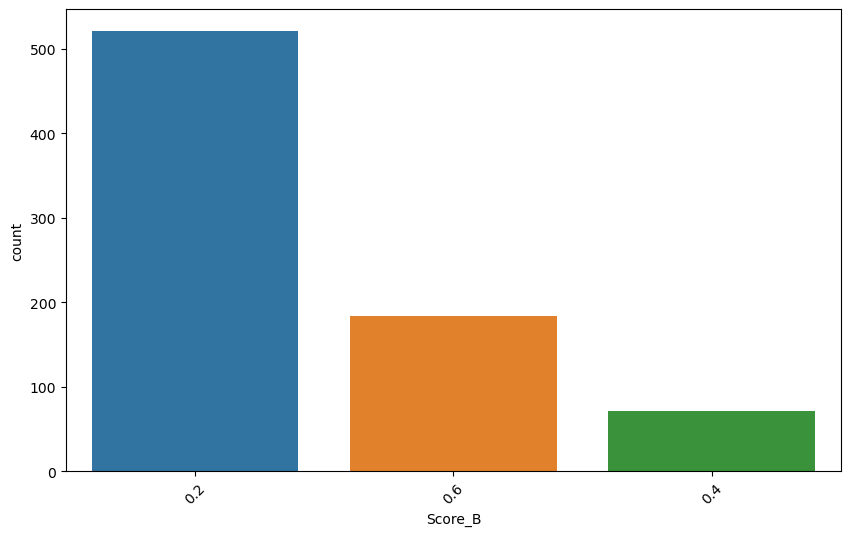

In [32]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Score_B'],order=df_auditRisk_data['Score_B'].value_counts().index)
plt.xticks(rotation=45)

This chart indicates that **Score_B** is also dominated by the value **0.2** with **about 520 records**, followed by **0.6** with **about 185 records**, while **0.4** appears least often with **about 70 records**. This indicates that most observations fall within the lowest Score_B category.


(array([0, 1, 2]), [Text(0, 0, '0.2'), Text(1, 0, '0.6'), Text(2, 0, '0.4')])

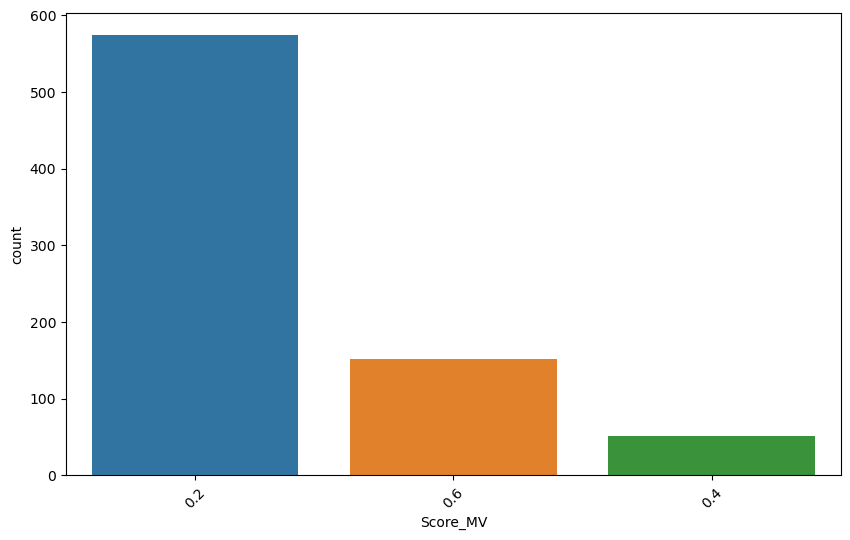

In [33]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Score_MV'],order=df_auditRisk_data['Score_MV'].value_counts().index)
plt.xticks(rotation=45)

The **Score_MV** is dominated by the value **0.2** with **about 575 records**, followed by **0.6** with **about 150 records**, while **0.4** appears least often with **about 50 records**. This indicates that the feature is concentrated in a few discrete categories, with lower score levels dominating the dataset. 

(array([0, 1, 2]), [Text(0, 0, '2'), Text(1, 0, '6'), Text(2, 0, '4')])

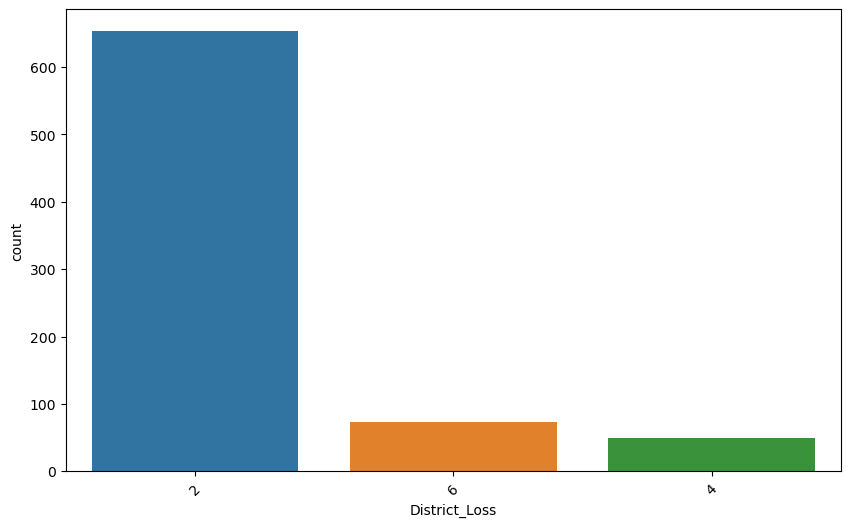

In [34]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['District_Loss'],order=df_auditRisk_data['District_Loss'].value_counts().index)
plt.xticks(rotation=45)

The **District_Loss** is concentrated mostly at **2** with **about 655 records**, followed by **6** with **about 75 records**, while **4** has **about 50 records**. This shows that most of the observations fall in the lowest district loss category.


(array([0, 1, 2]), [Text(0, 0, '0.2'), Text(1, 0, '0.4'), Text(2, 0, '0.6')])

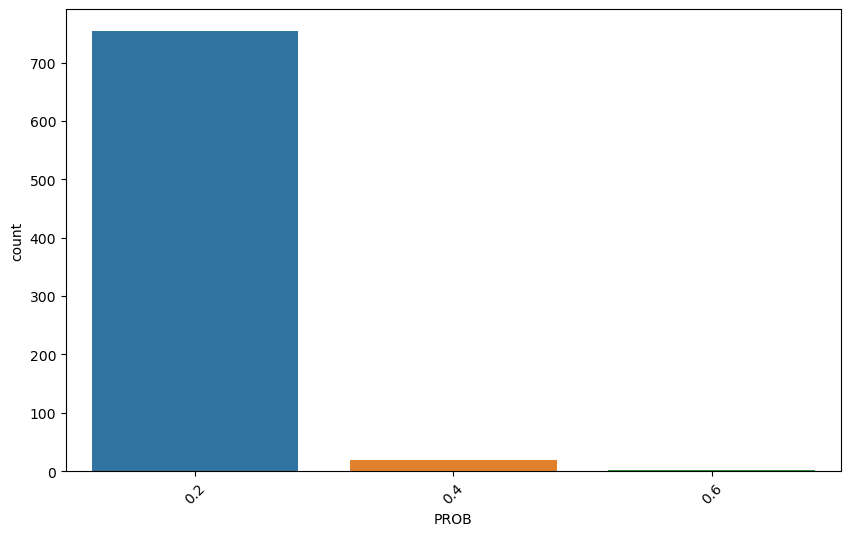

In [35]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['PROB'],order=df_auditRisk_data['PROB'].value_counts().index)
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '9'),
  Text(6, 0, '5')])

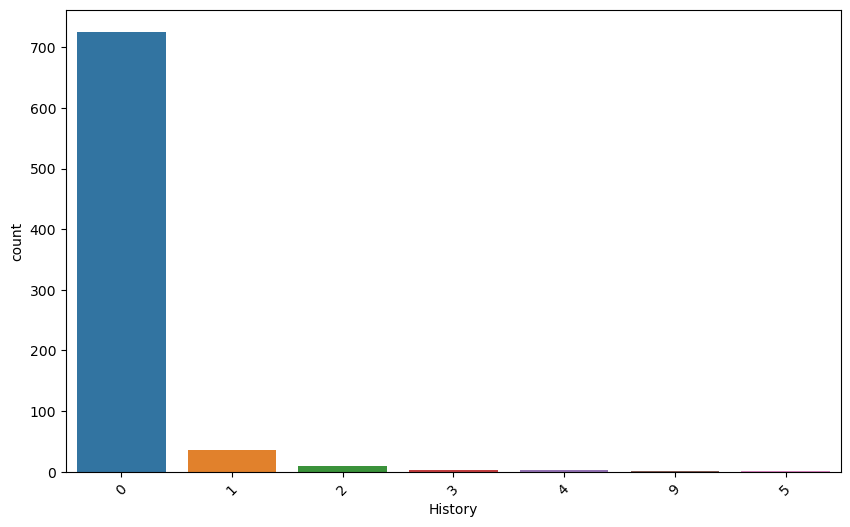

In [36]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['History'],order=df_auditRisk_data['History'].value_counts().index)
plt.xticks(rotation=45)

(array([0, 1, 2]), [Text(0, 0, '0.2'), Text(1, 0, '0.4'), Text(2, 0, '0.6')])

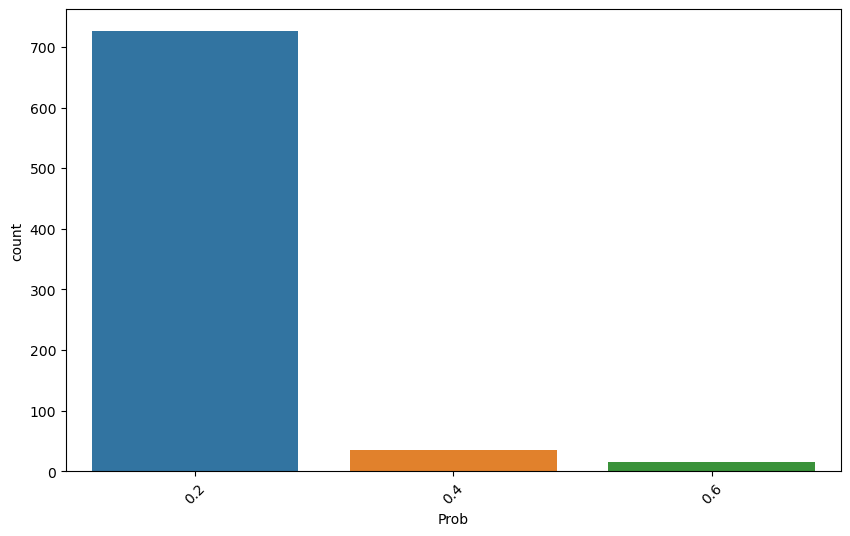

In [37]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Prob'],order=df_auditRisk_data['Prob'].value_counts().index)
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 [Text(0, 0, '2.0'),
  Text(1, 0, '2.2'),
  Text(2, 0, '2.4'),
  Text(3, 0, '2.6'),
  Text(4, 0, '4.0'),
  Text(5, 0, '4.2'),
  Text(6, 0, '3.6'),
  Text(7, 0, '3.8'),
  Text(8, 0, '3.2'),
  Text(9, 0, '4.4'),
  Text(10, 0, '2.8'),
  Text(11, 0, '3.0'),
  Text(12, 0, '3.4'),
  Text(13, 0, '4.8'),
  Text(14, 0, '4.6'),
  Text(15, 0, '5.2'),
  Text(16, 0, '5.0')])

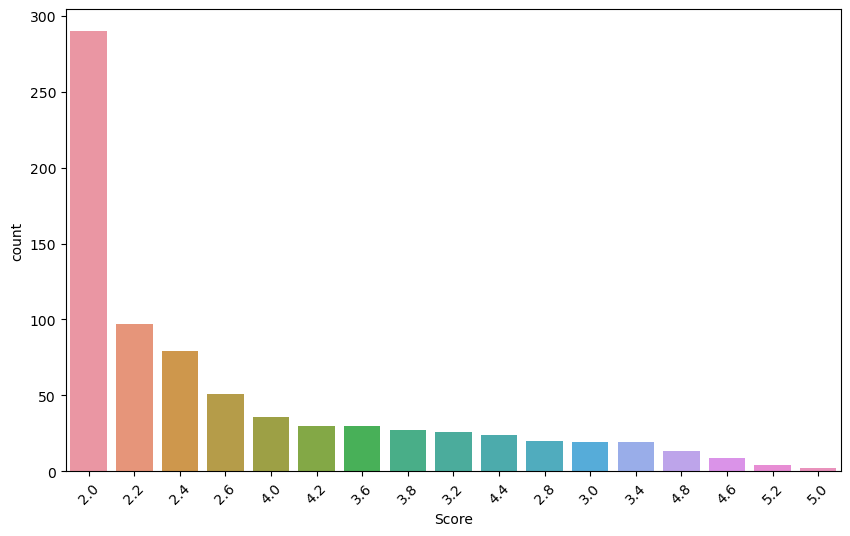

In [38]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['Score'],order=df_auditRisk_data['Score'].value_counts().index)
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, '0.4'),
  Text(1, 0, '0.8'),
  Text(2, 0, '1.2'),
  Text(3, 0, '1.6'),
  Text(4, 0, '2.4'),
  Text(5, 0, '2.2'),
  Text(6, 0, '2.0'),
  Text(7, 0, '5.8'),
  Text(8, 0, '3.4'),
  Text(9, 0, '4.8'),
  Text(10, 0, '3.6')])

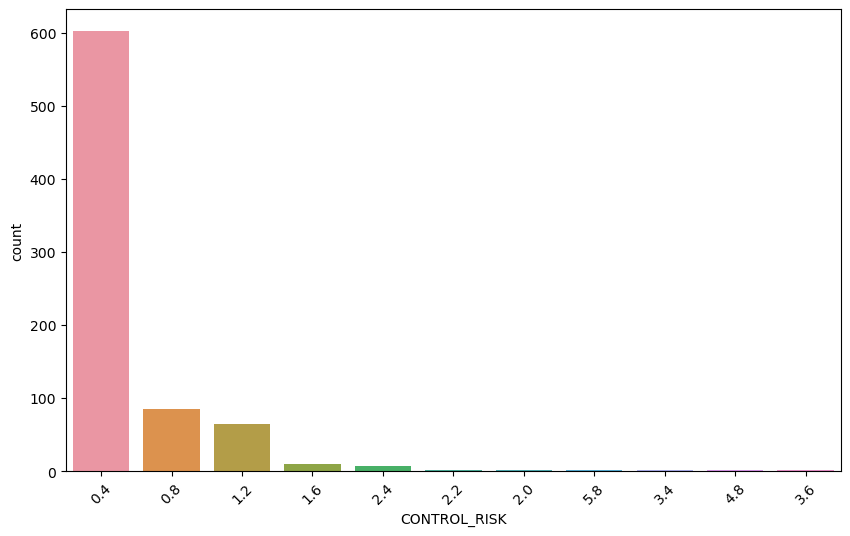

In [39]:
# Visualizing the count of Sector_score
plt.figure(figsize=(10,6))
sns.countplot(df_auditRisk_data['CONTROL_RISK'],order=df_auditRisk_data['CONTROL_RISK'].value_counts().index)
plt.xticks(rotation=45)

**Checking The Skewness**

In [40]:
# Lets have a look at the skewness
df_auditRisk_data.skew()

Sector_score       0.769987
PARA_A             8.505663
Score_A            0.492813
Risk_A             8.356859
PARA_B            20.538288
Score_B            0.960477
Risk_B            20.506060
TOTAL             19.261745
numbers            6.742206
Score_B.1          3.555230
Risk_C             3.995796
Money_Value       10.536120
Score_MV           1.297880
Risk_D            10.526293
District_Loss      2.231033
PROB               6.560046
RiSk_E             3.011444
History            9.275458
Prob               4.348489
Risk_F            10.391711
Score              1.055717
Inherent_Risk      9.170031
CONTROL_RISK       5.158719
Detection_Risk     0.000000
Audit_Risk        20.108965
Risk               0.438822
dtype: float64

**Removing The Skewness**

In [41]:
# Removing skewness using the cuberoot method

df_auditRisk_data['PARA_B'] = np .cbrt(df_auditRisk_data['PARA_B'])
df_auditRisk_data['Risk_B'] = np .cbrt(df_auditRisk_data['Risk_B'])
df_auditRisk_data['TOTAL'] = np .cbrt(df_auditRisk_data['TOTAL'])
df_auditRisk_data['Money_Value'] = np .cbrt(df_auditRisk_data['Money_Value'])
df_auditRisk_data['Risk_D'] = np .cbrt(df_auditRisk_data['Risk_D'])
df_auditRisk_data['Risk_F'] = np .cbrt(df_auditRisk_data['Risk_F'])
df_auditRisk_data['Audit_Risk'] = np .cbrt(df_auditRisk_data['Audit_Risk'])

We have now removed the skewness using the cube root method.

In [42]:
# Let us Check the skewness once again
df_auditRisk_data.skew()

Sector_score      0.769987
PARA_A            8.505663
Score_A           0.492813
Risk_A            8.356859
PARA_B            1.657518
Score_B           0.960477
Risk_B            1.792564
TOTAL             1.550055
numbers           6.742206
Score_B.1         3.555230
Risk_C            3.995796
Money_Value       2.065812
Score_MV          1.297880
Risk_D            2.235225
District_Loss     2.231033
PROB              6.560046
RiSk_E            3.011444
History           9.275458
Prob              4.348489
Risk_F            4.101117
Score             1.055717
Inherent_Risk     9.170031
CONTROL_RISK      5.158719
Detection_Risk    0.000000
Audit_Risk        2.855223
Risk              0.438822
dtype: float64

We can see the reduction in the level of skewness.

**Visualizing the data distribution in the columns after removing the skewness**.

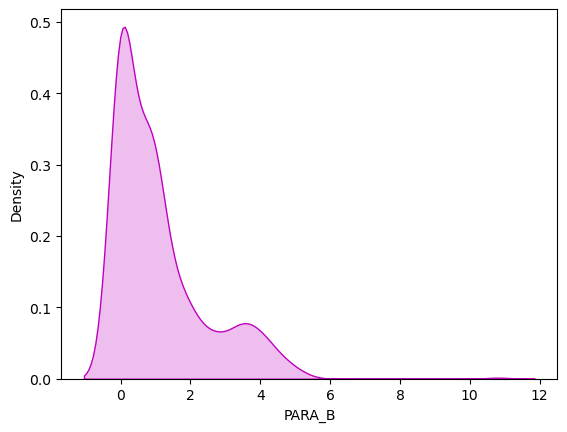

In [43]:
# Data distribution in PARA_B after skewness
sns.distplot(df_auditRisk_data['PARA_B'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The above distribution is strongly right-skewed,while most of the values are concentrated at the low end, roughly between 0 and 2.

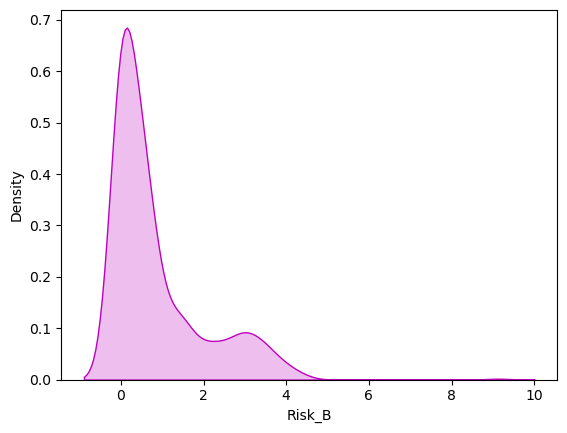

In [44]:
# Data distribution in Risk_B after skewness
sns.distplot(df_auditRisk_data['Risk_B'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

Risk_B above is heavily right-skewed, with most values clustered near 0 to 1. There is a small secondary bump around 3 which suggests slight heterogeneity, and a long tail with a few high-value outliers.


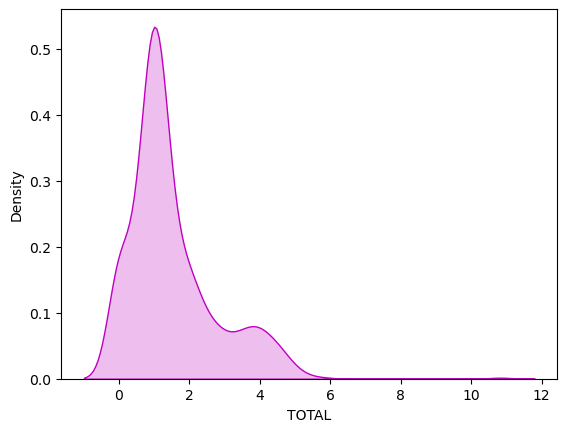

In [45]:
# Data distribution in Score_A after skewness
sns.distplot(df_auditRisk_data['TOTAL'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The above is positively(+vely) skewed, with most values concentrated between about 0 and 2. The long right tail is an indication of a few high-value outliers.


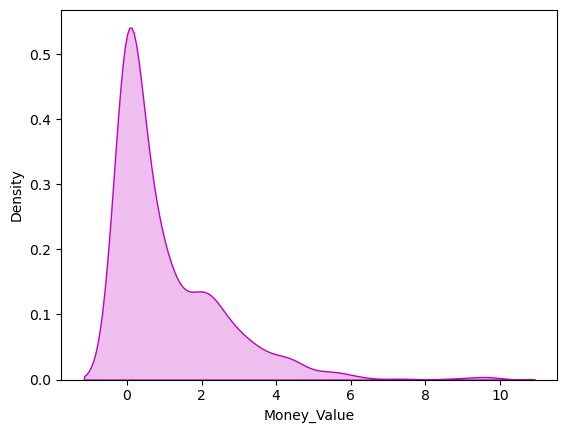

In [46]:
# Data distribution in Money_Value after skewness
sns.distplot(df_auditRisk_data['Money_Value'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

Money_Value is strongly right-skewed, with most observations clustered at low values near 0 to 2. The distribution has a main peak near zero, then gradually fades off with a long right tail, indicating a few larger values and possible outliers.


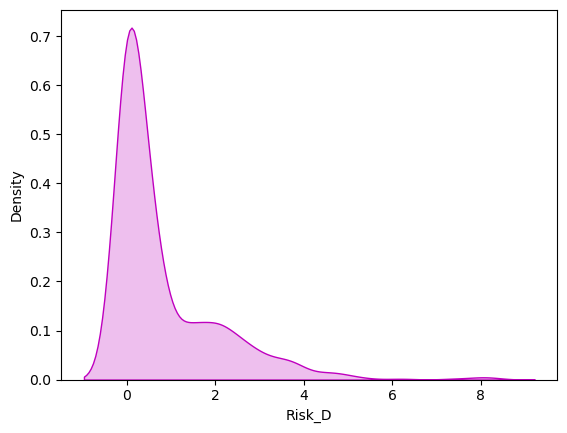

In [47]:
# Data distribution in Risk_D after skewness
sns.distplot(df_auditRisk_data['Risk_D'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

**Risk_D** is highly right-skewed, with most values concentrated near 0 to 1. The curve eases gradually to the right, showing a long tail and a few larger values that may be outliers.


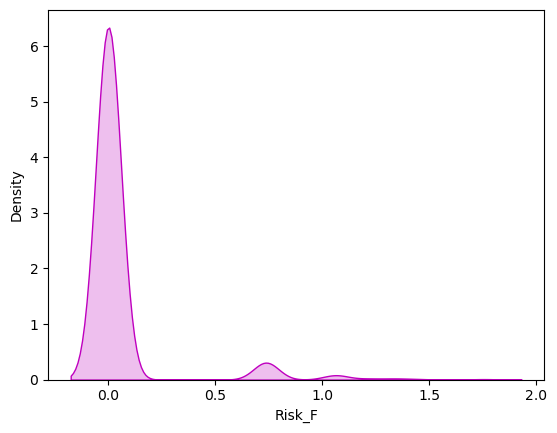

In [48]:
# Data distribution in Risk_F after skewness
sns.distplot(df_auditRisk_data['Risk_F'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

**Risk_F** is extremely concentrated near 0, showing a very sharp peak and strong right skew.

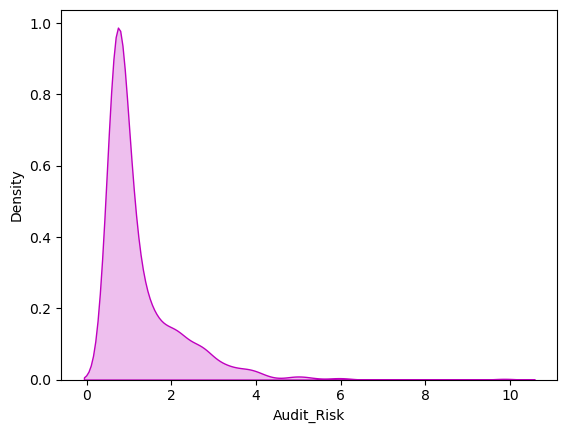

In [49]:
# Data distribution in Audit_Risk after skewness
sns.distplot(df_auditRisk_data['Audit_Risk'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

**Audit_Risk** is strongly right-skewed, with most values clustered at the lower end, around 0 to 2. The distribution declines steadily with a long right tail, indicating a small number of much higher values or outliers.


**Bivariate analysis**

Exploring relationships between the target and feature variables

<AxesSubplot:title={'center':'Sector_score in relation with Target(Risk)'}, xlabel='Sector_score', ylabel='Risk'>

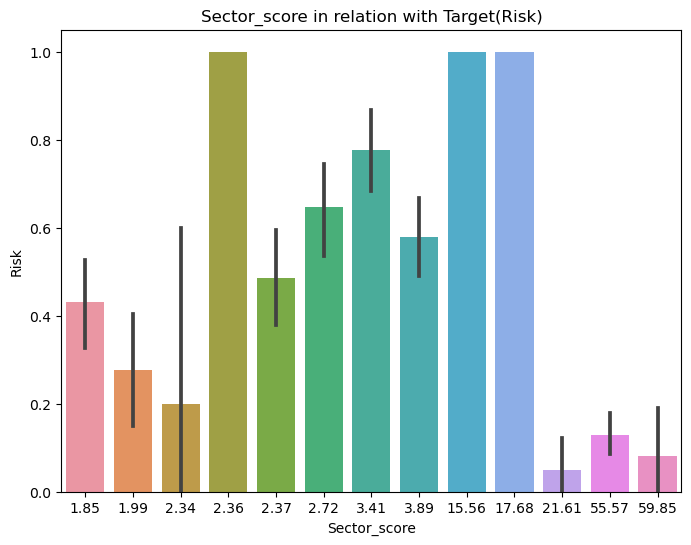

In [50]:
# barplot for Sector_score in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Sector_score in relation with Target(Risk)")
sns.barplot(x = 'Sector_score', y = 'Risk', data = df_auditRisk_data)

This chart shows that **risk levels vary notably across sector score categories**. Values such as **15.56** and **17.68** are associated with the highest observed risk, while **2.36** also shows a very high risk level. In contrast, sector scores like **21.61**, **55.57**, and **59.85** correspond to much lower risk values. This indicates that the Sector_score is an important predictor of the target.

<AxesSubplot:title={'center':'Score_A in relation with Target(Risk)'}, xlabel='Score_A', ylabel='Risk'>

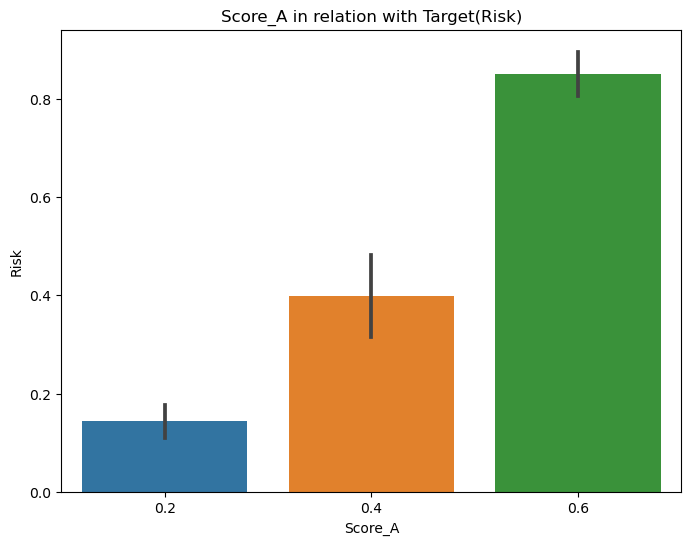

In [51]:
# barplot for Sector_score in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Score_A in relation with Target(Risk)")
sns.barplot(x = 'Score_A', y = 'Risk', data = df_auditRisk_data)

This chart shows a clear positive(+ve) relationship between **Score_A** and the target **Risk**. As Score_A increases from **0.2** to **0.6**, the average risk level rises substantially, from about **0.15** to **0.85**. This suggests that Score_A is a strong indicator of reported risk, with higher values being associated with a much greater likelihood of high-risk classification.


<AxesSubplot:title={'center':'Score_B in relation with Target(Risk)'}, xlabel='Score_B', ylabel='Risk'>

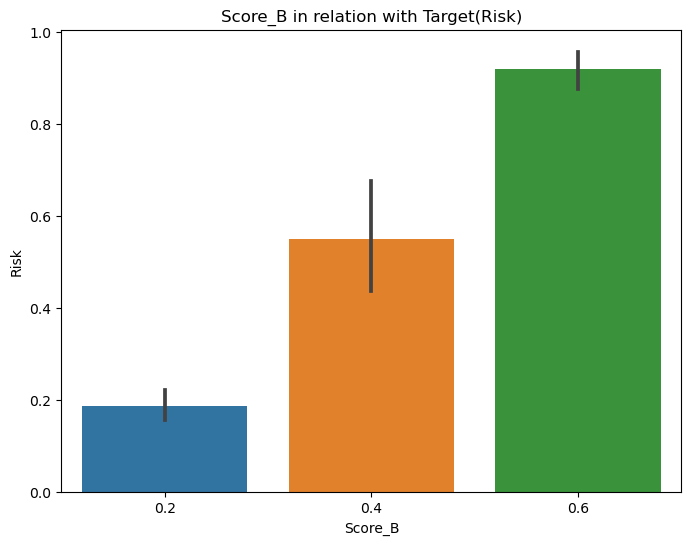

In [52]:
# barplot for Sector_score in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Score_B in relation with Target(Risk)")
sns.barplot(x = 'Score_B', y = 'Risk', data = df_auditRisk_data)

This chart shows a strong positive(+ve) relationship between **Score_B** and **Risk**. As Score_B increases from **0.2** to **0.6**, the average risk rises sharply from about **0.19** to **0.92**. This indicates that Score_B is a strong predictor of the target, with higher score levels being associated with a much greater likelihood of high risk.


<AxesSubplot:title={'center':'numbers in relation with Target(Risk)'}, xlabel='numbers', ylabel='Risk'>

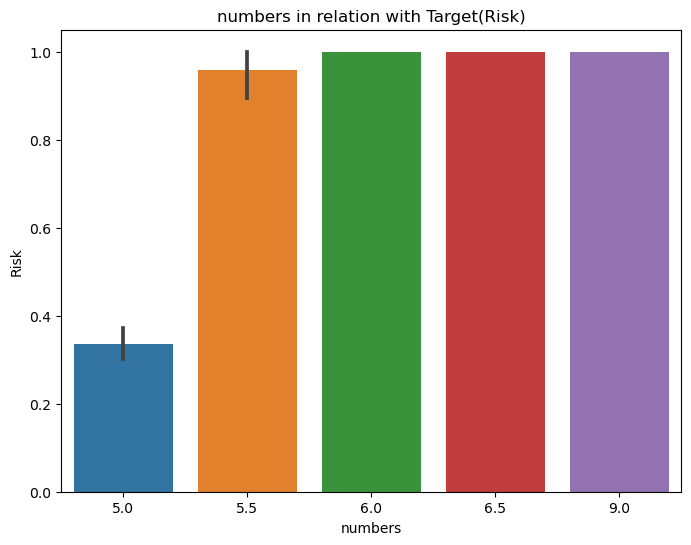

In [53]:
# barplot for Risk_B in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("numbers in relation with Target(Risk)")
sns.barplot(x = 'numbers', y = 'Risk', data = df_auditRisk_data)

The above chart shows that **Risk increases sharply as **numbers** rises. At **5.0**, the average risk is relatively low at about **0.33**, but it jumps to around **0.96** at **5.5** and reaches **1.00** for **6.0**, **6.5**, and **9.0**. This indicates that **numbers** is a very strong predictor of the target, with higher values being strongly associated with high-risk classification.


<AxesSubplot:title={'center':'Score_B.1 in relation with Target(Risk)'}, xlabel='Score_B.1', ylabel='Risk'>

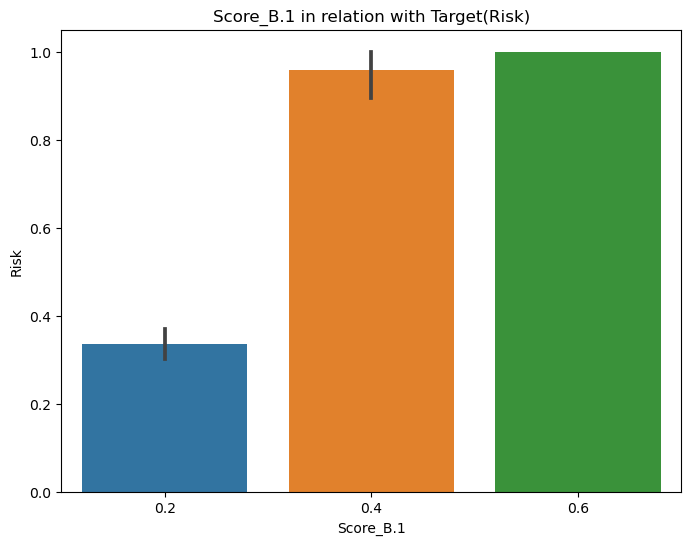

In [54]:
# barplot for Risk_B in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Score_B.1 in relation with Target(Risk)")
sns.barplot(x = 'Score_B.1', y = 'Risk', data = df_auditRisk_data)

This chart shows a strong positive(+ve) relationship between **Score_B.1** and **Risk**. At **0.2**, the average risk is relatively low at about **0.33**, but it rises sharply to around **0.96** at **0.4** and reaches **1.00** at **0.6**. This indicates that **Score_B.1** is a very strong predictor of the target, with higher values closely associated with high-risk classification.


<AxesSubplot:title={'center':'Risk_C in relation with Target(Risk)'}, xlabel='Risk_C', ylabel='Risk'>

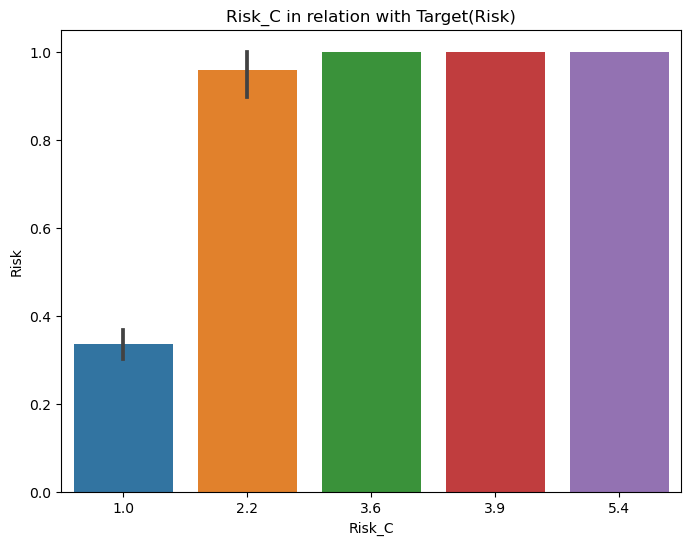

In [55]:
# barplot for Risk_C in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Risk_C in relation with Target(Risk)")
sns.barplot(x = 'Risk_C', y = 'Risk', data = df_auditRisk_data)

The chart indicates that **Risk rises consistently with higher **Risk_C** values. At **1.0**, the average risk is relatively low at about **0.33**, but it increases sharply to around **0.96** at **2.2** and reaches **1.00** for **3.6**, **3.9**, and **5.4**. This suggests that **Risk_C** is a very strong predictor of the target, with higher values being strongly associated with high-risk classification.


<AxesSubplot:title={'center':'Score_MV in relation with Target(Risk)'}, xlabel='Score_MV', ylabel='Risk'>

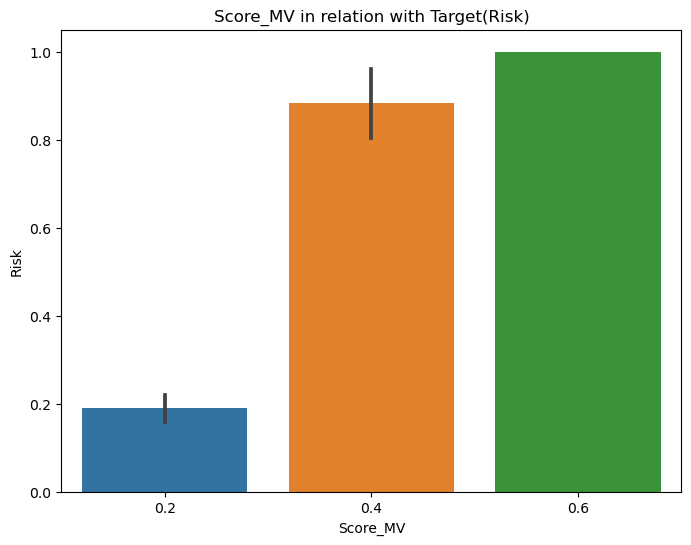

In [56]:
# barplot for Score_MV in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Score_MV in relation with Target(Risk)")
sns.barplot(x = 'Score_MV', y = 'Risk', data = df_auditRisk_data)

This chart shows a strong positive relationship between **Score_MV** and **Risk**. At **0.2**, the average risk is low at about **0.19**, but it rises sharply to around **0.88** at **0.4** and reaches **1.00** at **0.6**. This suggests that **Score_MV** is a strong predictor of the target, with higher values closely associated with high-risk classification.


<AxesSubplot:title={'center':'District_Loss in relation with Target(Risk)'}, xlabel='District_Loss', ylabel='Risk'>

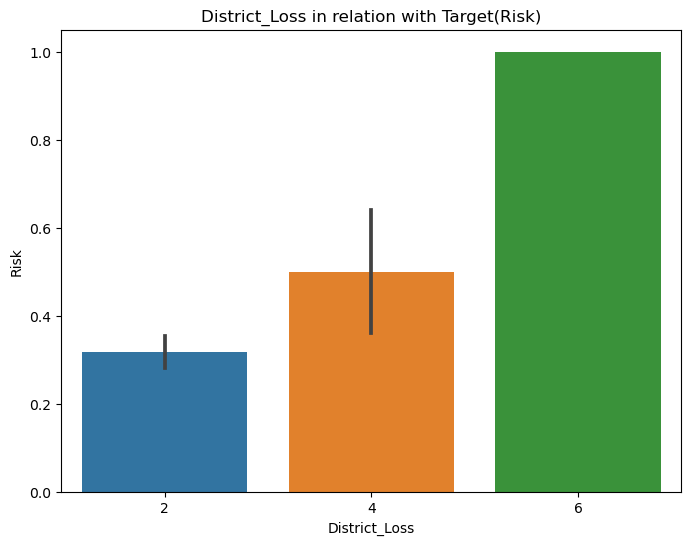

In [57]:
# barplot for District_Loss in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("District_Loss in relation with Target(Risk)")
sns.barplot(x = 'District_Loss', y = 'Risk', data = df_auditRisk_data)

This chart indicates that Risk increases with higher **District_Loss** values. At **2**, the average risk is about **0.32**, rising to around **0.50** at **4**, and reaching **1.00** at **6**. This suggests that **District_Loss** is a meaningful predictor of the target, with higher values associated with a greater likelihood of high-risk classification.


<AxesSubplot:title={'center':'PROB in relation with Target(Risk)'}, xlabel='PROB', ylabel='Risk'>

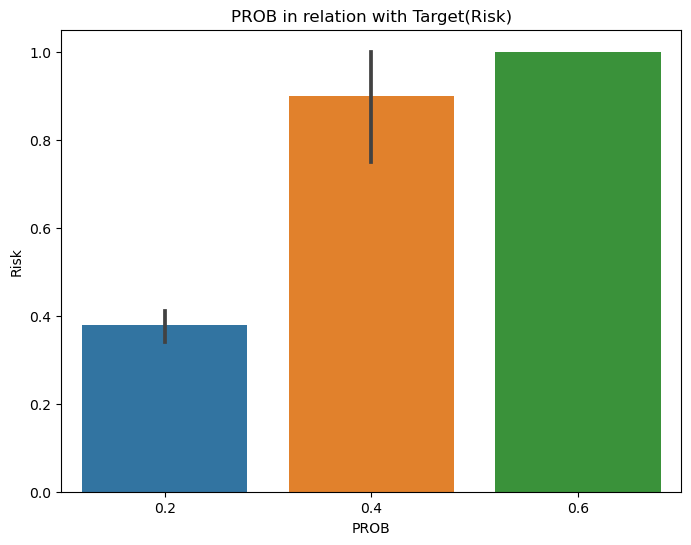

In [58]:
# barplot for PROB in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("PROB in relation with Target(Risk)")
sns.barplot(x = 'PROB', y = 'Risk', data = df_auditRisk_data)

The above chart shows a strong positive(+ve) relationship between **PROB** and **Risk**. At **0.2**, the average risk is about **0.38**, increasing sharply to around **0.90** at **0.4**, and reaching **1.00** at **0.6**. This suggests that **PROB** is a strong predictor of the target, with higher values closely associated with high-risk classification.


<AxesSubplot:title={'center':'RiSk_E in relation with Target(Risk)'}, xlabel='RiSk_E', ylabel='Risk'>

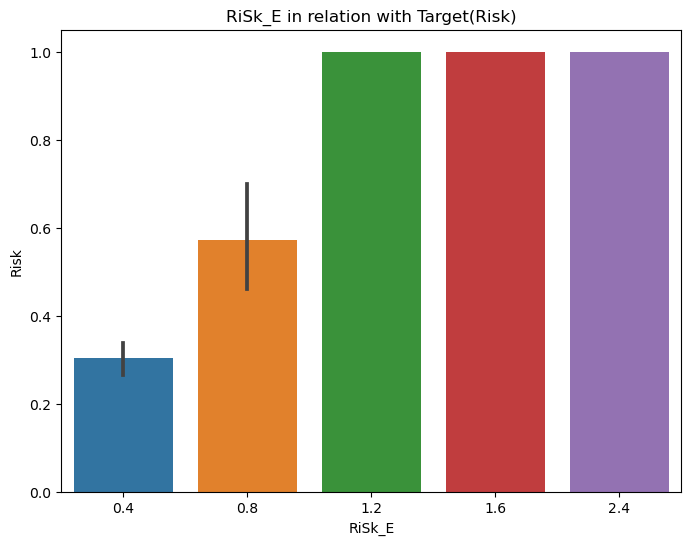

In [59]:
# barplot for RiSk_E in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("RiSk_E in relation with Target(Risk)")
sns.barplot(x = 'RiSk_E', y = 'Risk', data = df_auditRisk_data)

The chart indicates that Risk increases steadily with higher **RiSk_E** values**. At **0.4**, the average risk is about **0.30**, rising to around **0.57** at **0.8**, and reaching **1.00** at **1.2**, **1.6**, and **2.4**. This suggests that **RiSk_E** is a very strong predictor of the target, with higher values strongly associated with high-risk classification.


<AxesSubplot:title={'center':'History in relation with Target(Risk)'}, xlabel='History', ylabel='Risk'>

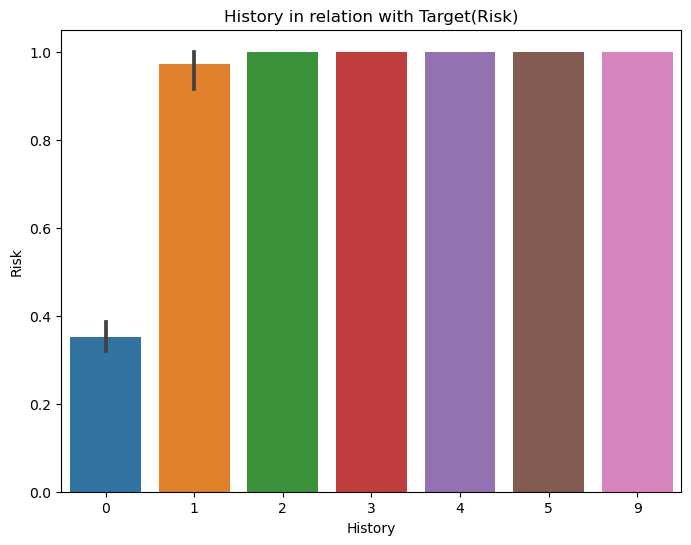

In [60]:
# barplot for History in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("History in relation with Target(Risk)")
sns.barplot(x = 'History', y = 'Risk', data = df_auditRisk_data)

The above chart shows that Risk increases sharply with higher **History values**. At **0**, the average risk is relatively low at about **0.35**, but it rises to around **0.97** at **1** and reaches **1.00** for **2, 3, 4, 5, and 9**. This suggests that **History** is a very strong predictor of the target, with higher values being strongly associated with high-risk classification.


<AxesSubplot:title={'center':'Prob in relation with Target(Risk)'}, xlabel='Prob', ylabel='Risk'>

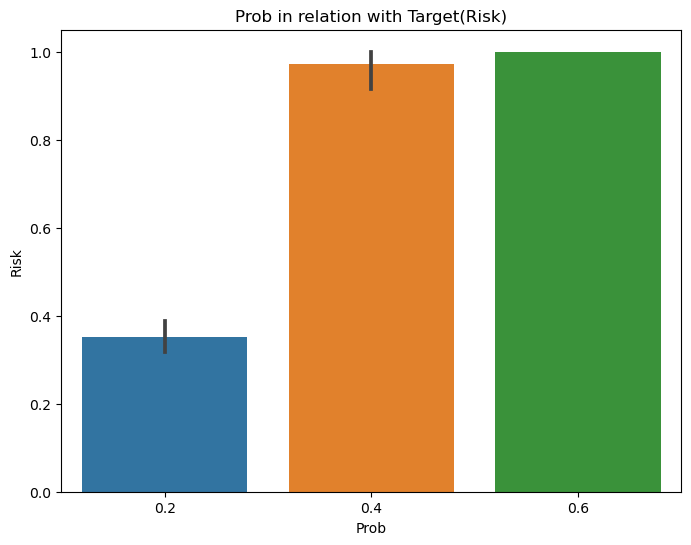

In [61]:
# barplot for Prob in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Prob in relation with Target(Risk)")
sns.barplot(x = 'Prob', y = 'Risk', data = df_auditRisk_data)

This chart shows a strong positive(+ve) relationship between **Prob** and **Risk**. At **0.2**, the average risk is about **0.35**, increasing sharply to around **0.97** at **0.4**, and reaching **1.00** at **0.6**. This suggests that **Prob** is a very strong predictor of the target, with higher values closely associated with high-risk classification.


<AxesSubplot:title={'center':'Score in relation with Target(Risk)'}, xlabel='Score', ylabel='Risk'>

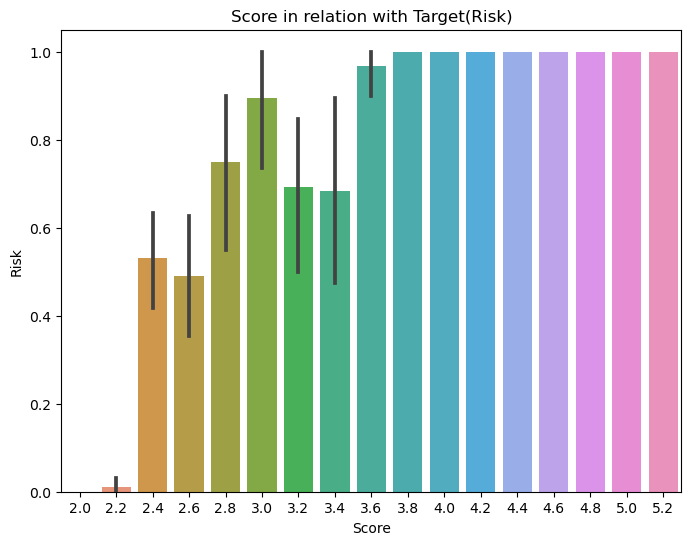

In [62]:
# barplot for Score in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Score in relation with Target(Risk)")
sns.barplot(x = 'Score', y = 'Risk', data = df_auditRisk_data)

This chart shows that Risk generally increases as **Score** rises. Very low score values, such as **2.2**, are associated with almost no risk, while mid-range values from about **2.4 to 3.4** show moderate to high risk with some variation. From around **3.6 upward**, the average risk is consistently close to **1.00**, indicating that higher **Score** values are strongly associated with high-risk classification.


<AxesSubplot:title={'center':'CONTROL_RISK in relation with Target(Risk)'}, xlabel='CONTROL_RISK', ylabel='Risk'>

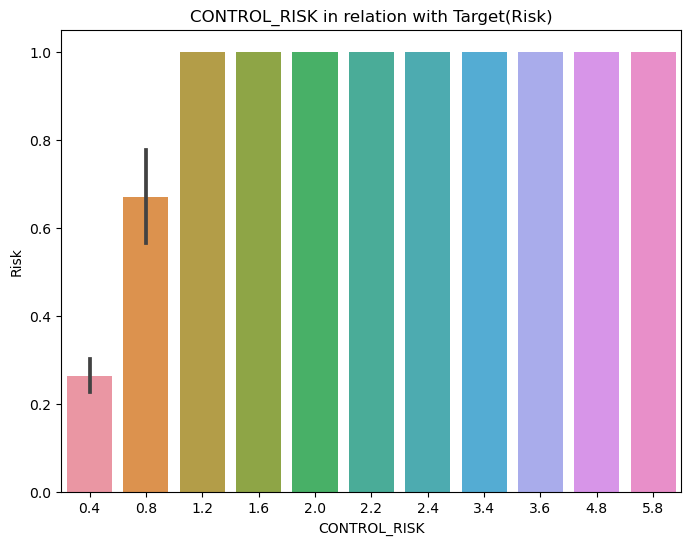

In [63]:
# barplot for CONTROL_RISK in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("CONTROL_RISK in relation with Target(Risk)")
sns.barplot(x = 'CONTROL_RISK', y = 'Risk', data = df_auditRisk_data)

The above chart shows that Risk increases strongly with higher **CONTROL_RISK** values. At **0.4**, the average risk is low at about **0.26**, rising to around **0.67** at **0.8**, and reaching **1.00** from **1.2** upward. This indicates that **CONTROL_RISK** is a very strong predictor of the target, with higher values being consistently associated with high-risk classification.


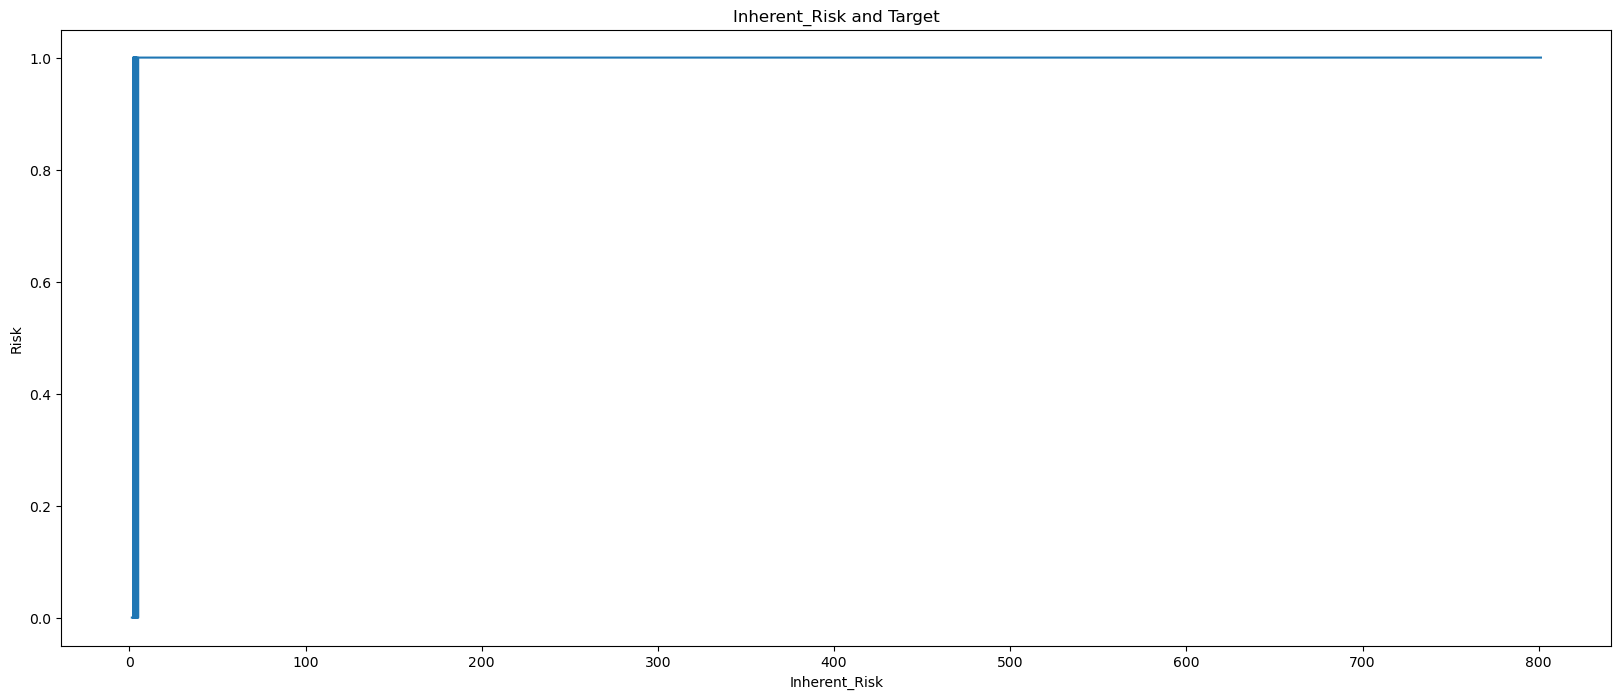

In [64]:
# Inherent_Risk and Target
plt.figure(figsize=(20, 8))
plt.title('Inherent_Risk and Target')
sns.lineplot(x='Inherent_Risk', y='Risk', data=df_auditRisk_data)
plt.show()

The above plot suggests an almost **perfect positive(+ve) relationship** between **Inherent_Risk** and the target **Risk**. Once **Inherent_Risk** moves above the very lowest level, the target remains at **1**, indicating that higher inherent risk values are consistently associated with high-risk classification. This implies that **Inherent_Risk** is an extremely strong predictor of the target and may be one of the most influential variables in the dataset.


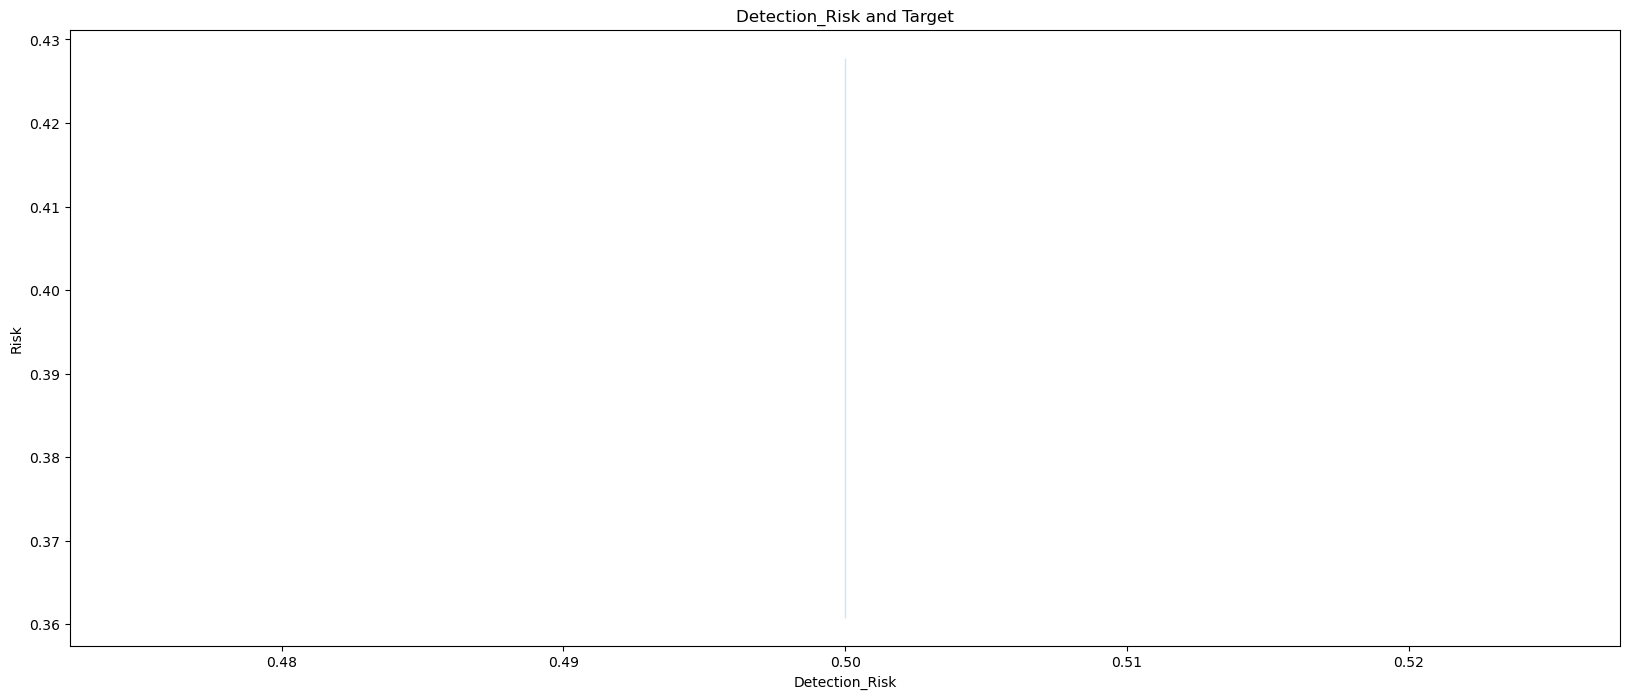

In [65]:
# Detection_Risk and Target
plt.figure(figsize=(20, 8))
plt.title('Detection_Risk and Target')
sns.lineplot(x='Detection_Risk', y='Risk', data=df_auditRisk_data)
plt.show()

This plot shows that **Detection_Risk** remains constant at 0.5 across the dataset, with no visible variation against the target **Risk**. This suggests that **Detection_Risk** does not provide meaningful discriminatory information for predicting the target, since it appears fixed for all observations. As a result, it is unlikely to contribute much to the classification of audit risk on its own.


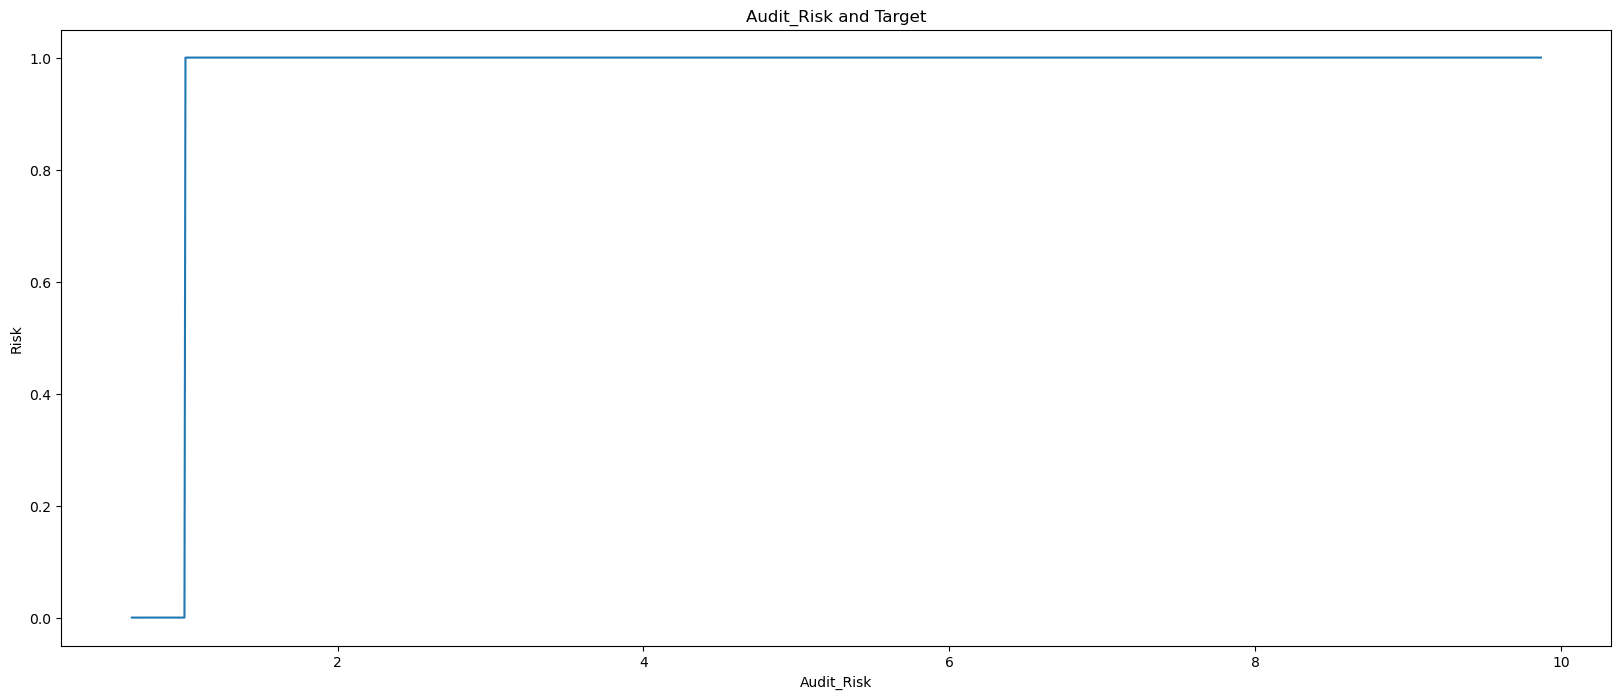

In [66]:
# Audit_Risk and Target 
plt.figure(figsize=(20, 8))
plt.title('Audit_Risk and Target')
sns.lineplot(x='Audit_Risk', y='Risk', data=df_auditRisk_data)
plt.show()

This plot shows an almost **perfect positive(+ve) relationship between **Audit_Risk** and the target **Risk**. At the very lowest audit risk level, the target remains **0**, but once **Audit_Risk** increases beyond that point, the target shifts to **1** and stays there. This indicates that **Audit_Risk** is an extremely strong predictor of the target and appears to separate low-risk from high-risk cases almost completely.


**Multivariate**

array([[<AxesSubplot:title={'center':'Sector_score'}>,
        <AxesSubplot:title={'center':'PARA_A'}>,
        <AxesSubplot:title={'center':'Score_A'}>,
        <AxesSubplot:title={'center':'Risk_A'}>,
        <AxesSubplot:title={'center':'PARA_B'}>,
        <AxesSubplot:title={'center':'Score_B'}>],
       [<AxesSubplot:title={'center':'Risk_B'}>,
        <AxesSubplot:title={'center':'TOTAL'}>,
        <AxesSubplot:title={'center':'numbers'}>,
        <AxesSubplot:title={'center':'Score_B.1'}>,
        <AxesSubplot:title={'center':'Risk_C'}>,
        <AxesSubplot:title={'center':'Money_Value'}>],
       [<AxesSubplot:title={'center':'Score_MV'}>,
        <AxesSubplot:title={'center':'Risk_D'}>,
        <AxesSubplot:title={'center':'District_Loss'}>,
        <AxesSubplot:title={'center':'PROB'}>,
        <AxesSubplot:title={'center':'RiSk_E'}>,
        <AxesSubplot:title={'center':'History'}>],
       [<AxesSubplot:title={'center':'Prob'}>,
        <AxesSubplot:title={'center':'Risk_F

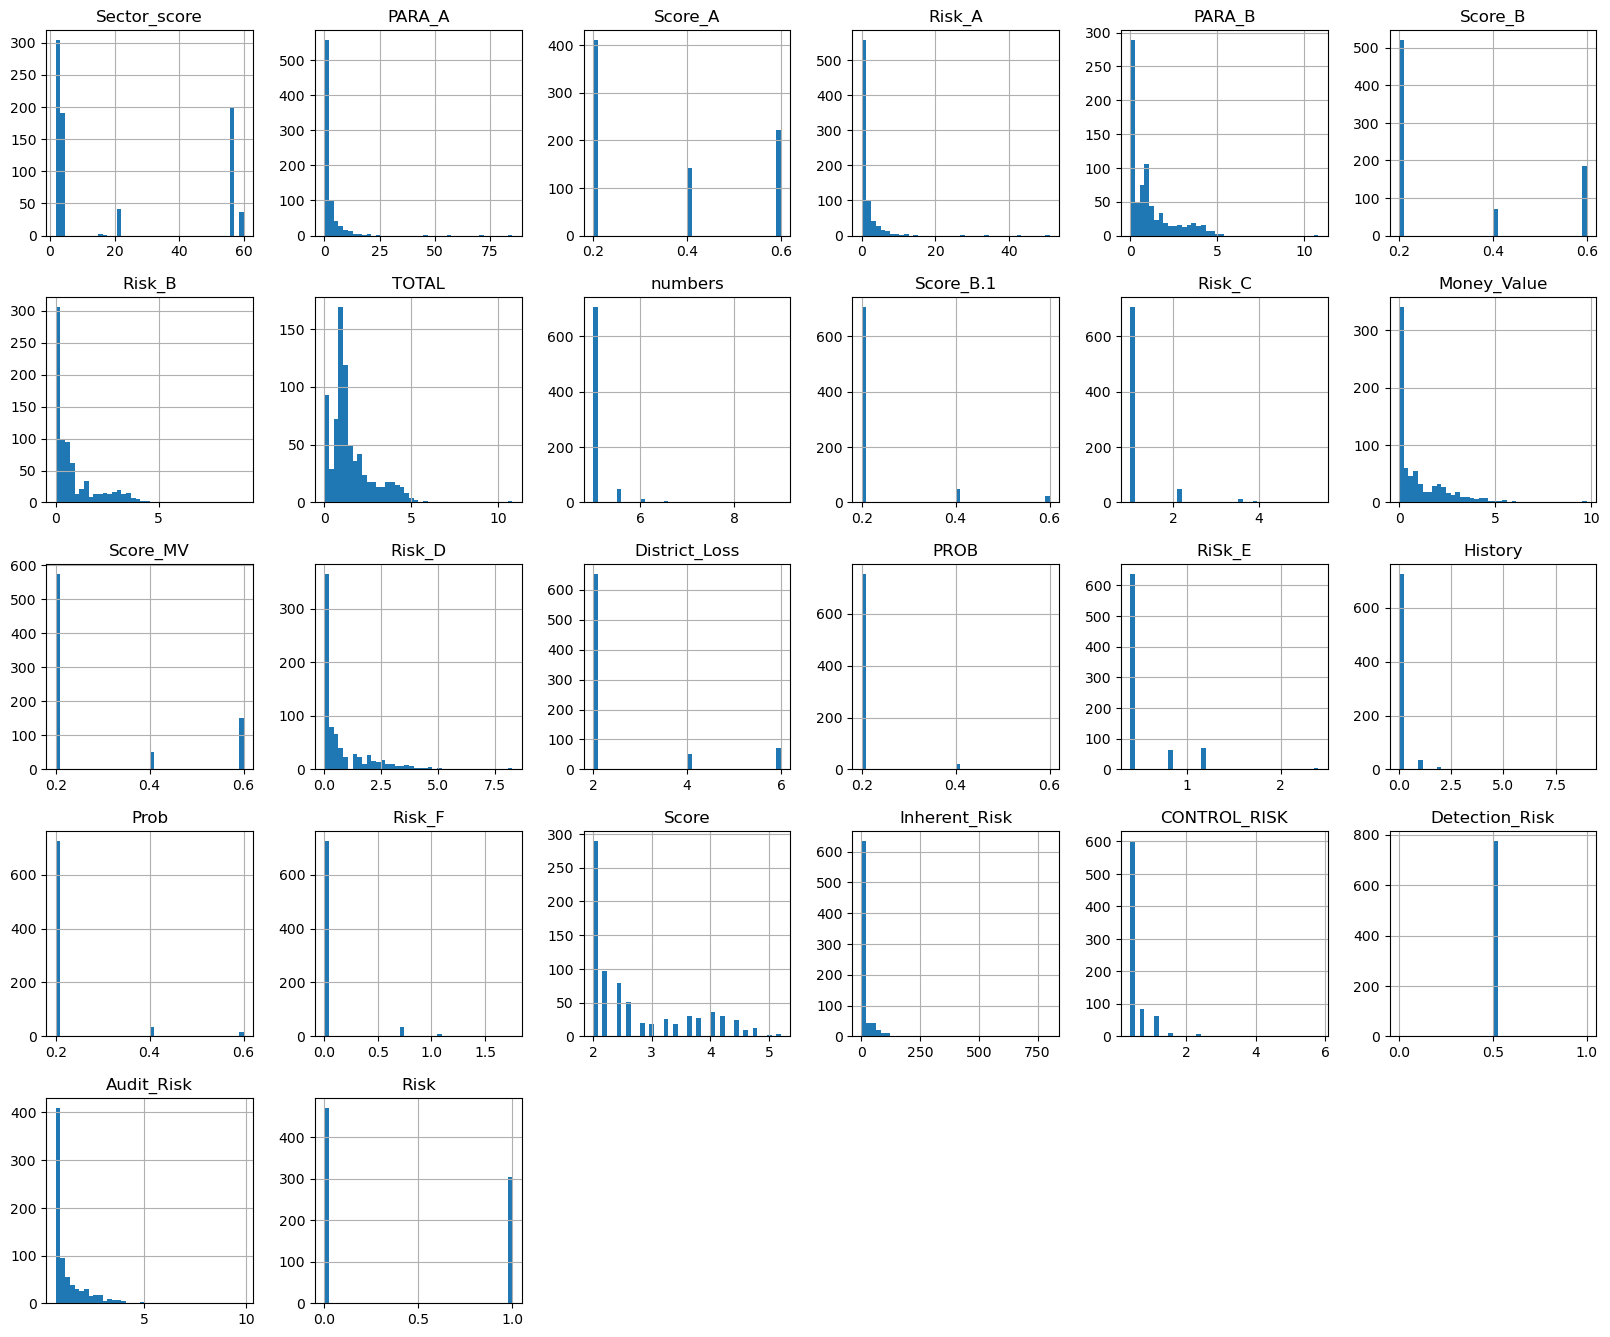

In [67]:
df_auditRisk_data.hist(figsize=(20,20), grid = True, layout = (6,6), bins = 40)

The histograms show that most features in the dataset are **not normally distributed** and are concentrated at lower values, with many displaying clear **right-skewness**. Variables such as **PARA_A**, **PARA_B**, **Risk_A**, **Risk_B**, **Risk_D**, **Money_Value**, **Inherent_Risk**, **CONTROL_RISK**, and **Audit_Risk** have long right tails, indicating that most observations fall at lower levels while a smaller number extend to much higher values. This suggests the presence of outliers and uneven spread across several audit-related features.

Several variables also appear to take on only a few discrete values, including **Score_A**, **Score_B**, **Score_B.1**, **Score_MV**, **PROB**, **Prob**, and **Risk**, showing that they behave more like categorical or ordinal indicators than continuous variables. Features such as **numbers**, **District_Loss**, and **History** are also concentrated in a limited set of values, with one category dominating in each case. In contrast, **Detection_Risk** remains nearly constant, which suggests it contributes very little variation to the dataset.

Overall, the distributions indicate that the dataset contains a mix of skewed continuous variables and highly concentrated discrete risk indicators. This pattern suggests that many of the predictors may already encode structured risk information, which could make them highly informative for classification.


### Correlation Analysis

**Correlation between Target variable and Independent Variables**.

In [68]:
# Checking the correlation between features and the target.
cor = df_auditRisk_data.corr()
cor

,Sector_score,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,Score_B.1,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
Sector_score,1.000000,-0.216824,-0.425198,-0.219025,-0.328837,-0.218967,-0.312336,-0.382616,-0.151840,-0.170404,...,-0.128546,-0.114798,-0.136900,-0.142033,-0.337326,-0.173278,-0.154950,NaN,-0.319261,-0.394131
PARA_A,-0.216824,1.000000,0.496680,0.999267,0.376214,0.358550,0.379335,0.513539,0.133786,0.140648,...,0.118941,0.118279,0.172635,0.170566,0.426659,0.481859,0.149198,NaN,0.487780,0.378758
Score_A,-0.425198,0.496680,1.000000,0.504878,0.579575,0.572655,0.580678,0.710024,0.242692,0.274594,...,0.102677,0.177932,0.265322,0.267789,0.720488,0.320920,0.170872,NaN,0.562102,0.619726
Risk_A,-0.219025,0.999267,0.504878,1.000000,0.382414,0.362971,0.385419,0.514962,0.135613,0.143103,...,0.118641,0.121132,0.176159,0.174104,0.432505,0.483291,0.150778,NaN,0.492649,0.385067
PARA_B,-0.328837,0.376214,0.579575,0.382414,1.000000,0.851598,0.995777,0.945784,0.335836,0.369508,...,0.009438,0.247986,0.364785,0.355897,0.841336,0.522571,0.156854,NaN,0.728636,0.625808
Score_B,-0.218967,0.358550,0.572655,0.362971,0.851598,1.000000,0.874640,0.807859,0.277576,0.313798,...,0.015324,0.200841,0.309505,0.306610,0.901276,0.365662,0.127827,NaN,0.611670,0.635768
Risk_B,-0.312336,0.379335,0.580678,0.385419,0.995777,0.874640,1.000000,0.946825,0.340631,0.374316,...,0.015641,0.248286,0.370869,0.360999,0.858762,0.532004,0.160686,NaN,0.740622,0.630403
TOTAL,-0.382616,0.513539,0.710024,0.514962,0.945784,0.807859,0.946825,1.000000,0.335048,0.364188,...,0.053215,0.253990,0.367551,0.357168,0.845454,0.548644,0.191146,NaN,0.758691,0.653346
numbers,-0.151840,0.133786,0.242692,0.135613,0.335836,0.277576,0.340631,0.335048,1.000000,0.908140,...,0.136956,0.202327,0.209598,0.204730,0.502827,0.271115,0.228657,NaN,0.444181,0.308141
Score_B.1,-0.170404,0.140648,0.274594,0.143103,0.369508,0.313798,0.374316,0.364188,0.908140,1.000000,...,0.157595,0.226177,0.248423,0.241439,0.565976,0.308543,0.256551,NaN,0.507009,0.353803


In [69]:
# Dropping the Detection_Risk column
df_auditRisk_data.drop('Detection_Risk',axis=1,inplace=True)

In [70]:
# Checking the correlation again.
cor = df_auditRisk_data.corr()
cor

,Sector_score,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,Score_B.1,...,PROB,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Audit_Risk,Risk
Sector_score,1.000000,-0.216824,-0.425198,-0.219025,-0.328837,-0.218967,-0.312336,-0.382616,-0.151840,-0.170404,...,-0.086750,-0.128546,-0.114798,-0.136900,-0.142033,-0.337326,-0.173278,-0.154950,-0.319261,-0.394131
PARA_A,-0.216824,1.000000,0.496680,0.999267,0.376214,0.358550,0.379335,0.513539,0.133786,0.140648,...,0.043707,0.118941,0.118279,0.172635,0.170566,0.426659,0.481859,0.149198,0.487780,0.378758
Score_A,-0.425198,0.496680,1.000000,0.504878,0.579575,0.572655,0.580678,0.710024,0.242692,0.274594,...,0.093648,0.102677,0.177932,0.265322,0.267789,0.720488,0.320920,0.170872,0.562102,0.619726
Risk_A,-0.219025,0.999267,0.504878,1.000000,0.382414,0.362971,0.385419,0.514962,0.135613,0.143103,...,0.043735,0.118641,0.121132,0.176159,0.174104,0.432505,0.483291,0.150778,0.492649,0.385067
PARA_B,-0.328837,0.376214,0.579575,0.382414,1.000000,0.851598,0.995777,0.945784,0.335836,0.369508,...,0.093153,0.009438,0.247986,0.364785,0.355897,0.841336,0.522571,0.156854,0.728636,0.625808
Score_B,-0.218967,0.358550,0.572655,0.362971,0.851598,1.000000,0.874640,0.807859,0.277576,0.313798,...,0.092567,0.015324,0.200841,0.309505,0.306610,0.901276,0.365662,0.127827,0.611670,0.635768
Risk_B,-0.312336,0.379335,0.580678,0.385419,0.995777,0.874640,1.000000,0.946825,0.340631,0.374316,...,0.097768,0.015641,0.248286,0.370869,0.360999,0.858762,0.532004,0.160686,0.740622,0.630403
TOTAL,-0.382616,0.513539,0.710024,0.514962,0.945784,0.807859,0.946825,1.000000,0.335048,0.364188,...,0.109473,0.053215,0.253990,0.367551,0.357168,0.845454,0.548644,0.191146,0.758691,0.653346
numbers,-0.151840,0.133786,0.242692,0.135613,0.335836,0.277576,0.340631,0.335048,1.000000,0.908140,...,0.035807,0.136956,0.202327,0.209598,0.204730,0.502827,0.271115,0.228657,0.444181,0.308141
Score_B.1,-0.170404,0.140648,0.274594,0.143103,0.369508,0.313798,0.374316,0.364188,0.908140,1.000000,...,0.036899,0.157595,0.226177,0.248423,0.241439,0.565976,0.308543,0.256551,0.507009,0.353803


Lets show this relationship by generating a heatmap plot.

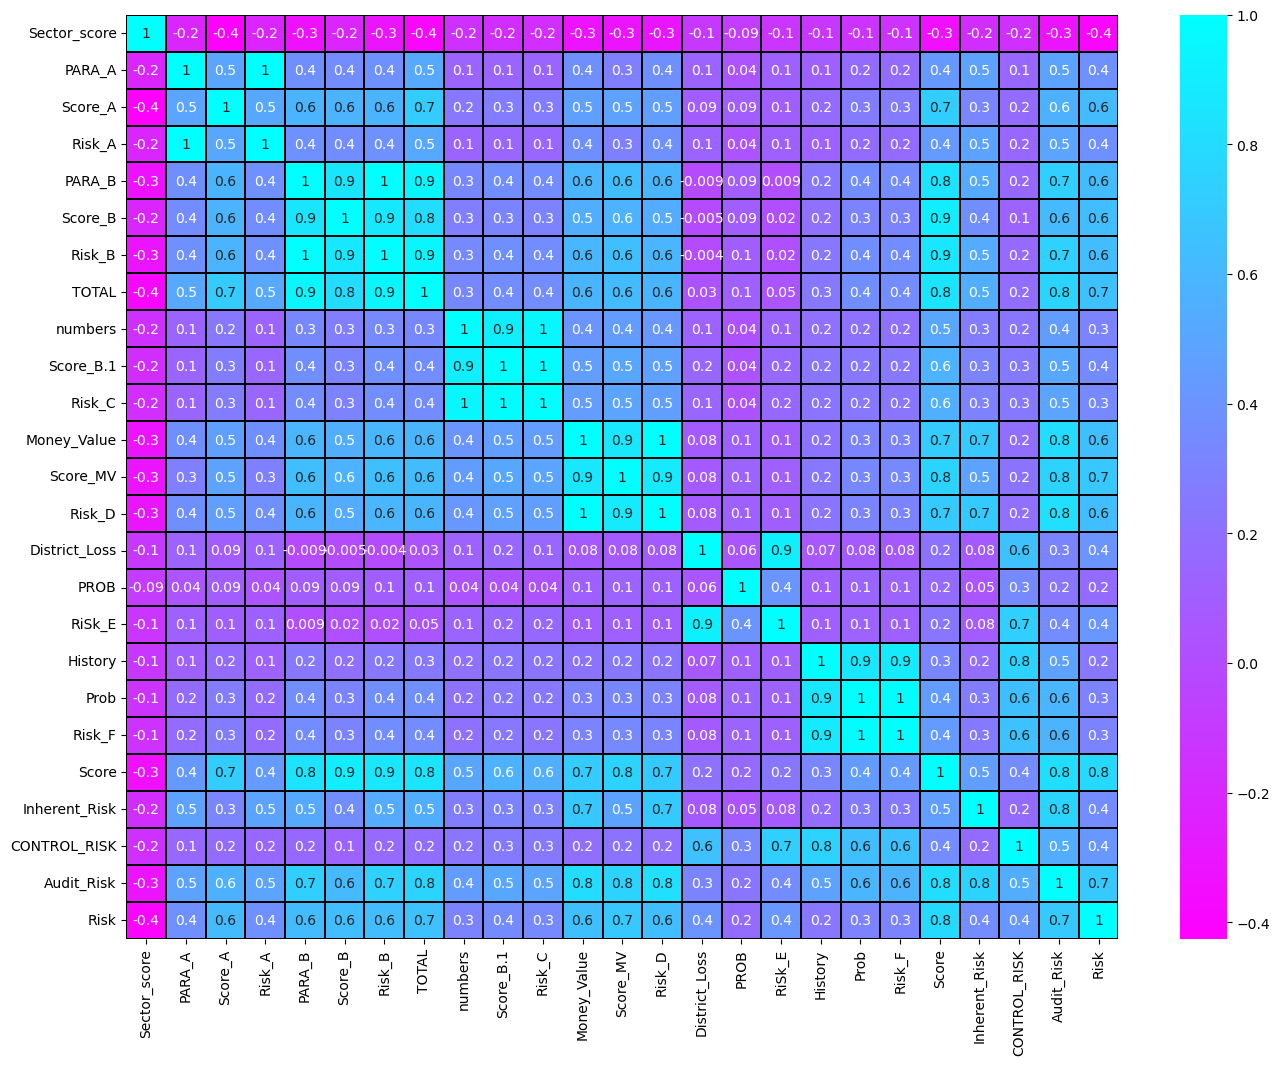

In [71]:
# Visualizing the correlation matrix by plotting heatmap
plt.figure(figsize = (16, 12))
sns.heatmap(df_auditRisk_data.corr(), linewidths = 0.1, fmt = ".1g", linecolor = "black", annot = True, cmap = "cool_r")
plt.yticks(rotation = 0);
plt.show()

*  **0- no relation, -0.3 to +0.3- less correlation, greater than -0.5 or greater than +0.5- moderate correlation, greater than -0.7**

The correlation heatmap shows that **Risk** has strong positive(+ve) relationships with several audit-related variables, especially **Score (0.8)**, **Audit_Risk (0.7)**, **Score_MV (0.7)**, and variables such as **Score_A**, **PARA_B**, **Score_B**, **Risk_B**, **TOTAL**, and **Risk_D** (mostly around **0.6**). This suggests that higher values in these features are strongly associated with higher reported risk. In contrast, **Sector_score** has a moderate negative correlation with **Risk** (**-0.4**), indicating that some sector categories may be linked to lower risk levels.

The heatmap also reveals strong intercorrelations among several predictors. For example, **PARA_A and Risk_A**, **PARA_B and Risk_B**, **Money_Value and Risk_D**, and **Prob and Risk_F** are very highly correlated, often around **0.9 to 1.0**. This suggests that some variables may carry overlapping information and could introduce multicollinearity in modeling.

In [72]:
# Computing the correlation of all numeric columns with Target
df_auditRisk_data.corr()['Risk'].sort_values(ascending = False)

Risk             1.000000
Score            0.785995
Audit_Risk       0.697881
Score_MV         0.688367
TOTAL            0.653346
Money_Value      0.642410
Risk_D           0.637769
Score_B          0.635768
Risk_B           0.630403
PARA_B           0.625808
Score_A          0.619726
CONTROL_RISK     0.416474
RiSk_E           0.411803
District_Loss    0.403806
Risk_A           0.385067
PARA_A           0.378758
Inherent_Risk    0.357020
Score_B.1        0.353803
Risk_C           0.342140
numbers          0.308141
Risk_F           0.305518
Prob             0.298639
History          0.239453
PROB             0.176912
Sector_score    -0.394131
Name: Risk, dtype: float64

All the features have the strongest positive relationship with Risk except for **Sector_score** which has a -ve correlation.

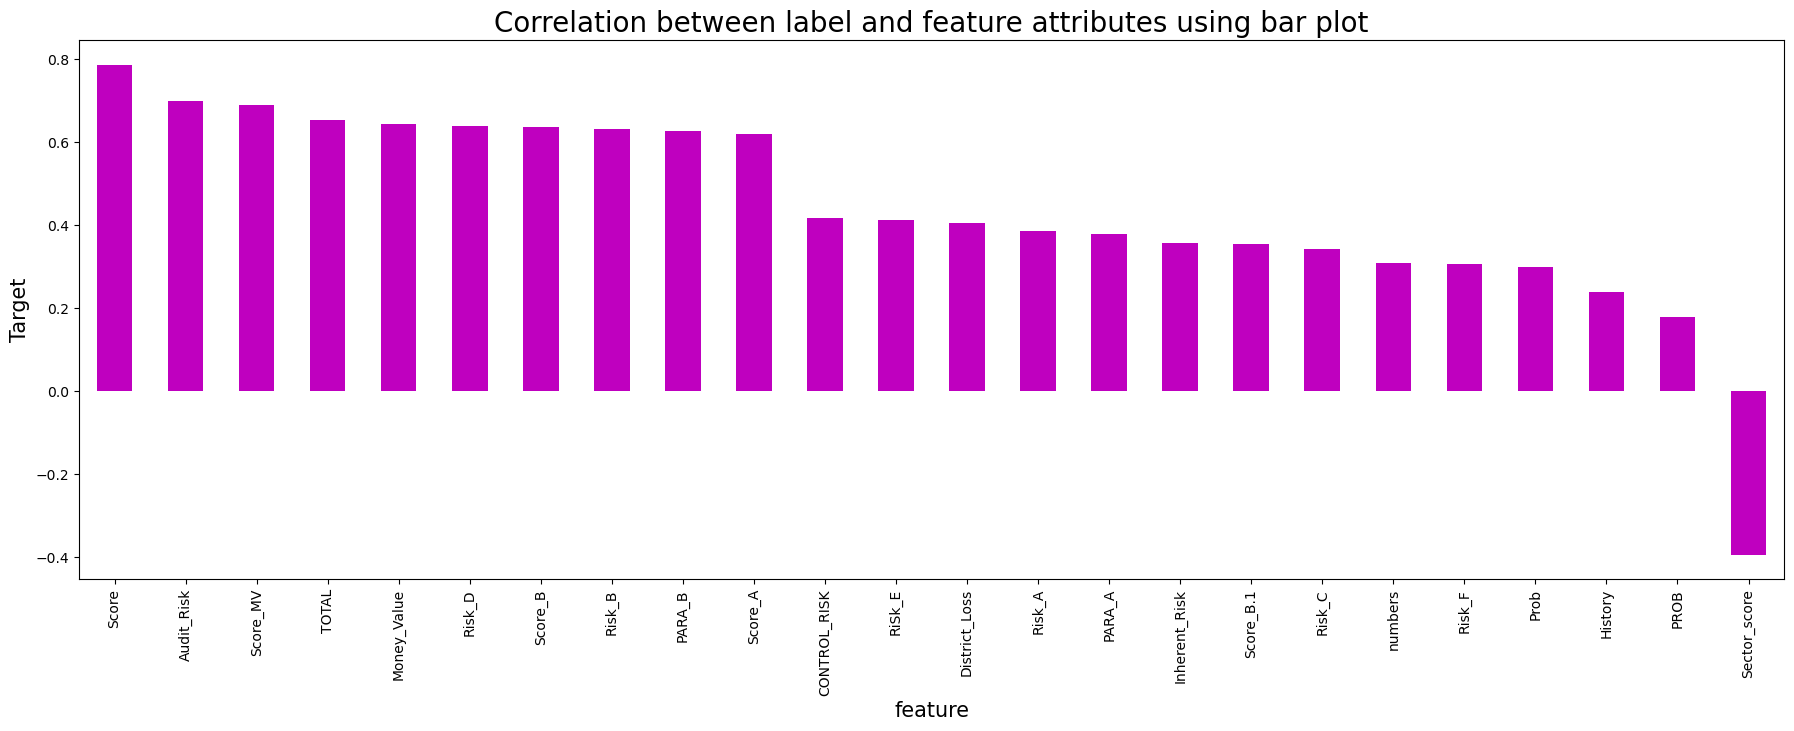

In [73]:
# Lets view the Correlation between label and feature attributes using bar plot
plt.figure(figsize = (22, 7))
df_auditRisk_data.corr()['Risk'].sort_values(ascending = False).drop(['Risk']).plot(kind='bar',color="m")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between label and feature attributes using bar plot", fontsize=20)
plt.show()

The above bar plot shows that **Score** has the strongest positive(+ve) correlation with the target, followed by **Audit_Risk** and **Score_MV**. Other variables such as **TOTAL**, **Money_Value**, **Risk_D**, **Score_B**, **Risk_B**, **PARA_B**, and **Score_A** also have moderately strong positive(+ve) relationships with **Risk**, indicating that they are important predictors of **audit risk**. In contrast, **Sector_score** has a noticeable negative(-ve) correlation, suggesting that higher sector scores are associated with lower reported risk. 

### Feature Engineering & Preprocessing

**SPLITING THE VARIABLES INTO FEATURES(X) AND TARGET(Y)**

In [74]:
# Identifying our independent variable (x) and dependant/target variable (y)
x = df_auditRisk_data.drop("LOCATION_ID", axis =1)
y = df_auditRisk_data["Risk"]

**Feature Scaling using standard scalarization**

In [75]:
# Encode categorical columns
x_encoded = x.copy()
for col in x_encoded.select_dtypes(include=['object']).columns:
    x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col])

In [76]:
# Scale the encoded data
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_encoded), columns=x_encoded.columns)

x_scaled.head()

,Sector_score,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,Score_B.1,...,PROB,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Audit_Risk,Risk
0,-0.670465,0.304800,1.429846,0.336502,0.205862,-0.666752,-0.041380,0.306929,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.352503,-0.166468,-0.388662,-0.052927,1.242684
1,-0.670465,-0.431736,-0.869761,-0.392943,0.457738,-0.666752,0.131770,0.150840,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.276513,-0.388662,-0.489901,-0.804710
2,-0.670465,-0.341872,-0.869761,-0.363277,-0.357002,-0.666752,-0.428315,-0.484882,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.294902,-0.388662,-0.624958,-0.804710
3,-0.670465,-0.431736,-0.869761,-0.392943,0.850900,1.690422,0.910095,0.571528,3.527894,4.686039,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,1.977497,-0.002753,-0.388662,0.301241,1.242684
4,-0.670465,-0.431736,-0.869761,-0.392943,-0.494450,-0.666752,-0.522802,-0.868011,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.297315,-0.388662,-0.646723,-0.804710


In [77]:
x_scaled.tail()

,Sector_score,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,Score_B.1,...,PROB,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Audit_Risk,Risk
771,1.455992,-0.345396,-0.869761,-0.364440,-0.263171,-0.666752,-0.363812,-0.438452,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.294354,-0.388662,-0.620185,-0.80471
772,1.455992,-0.348920,-0.869761,-0.365603,-0.277460,-0.666752,-0.373635,-0.453305,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.294537,-0.388662,-0.621769,-0.80471
773,1.455992,-0.389447,-0.869761,-0.378982,-0.561653,-0.666752,-0.569001,-0.687353,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.296584,-0.388662,-0.639990,-0.80471
774,1.455992,-0.396495,-0.869761,-0.381309,-0.820206,-0.666752,-0.746740,-0.743502,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.296876,-0.388662,-0.642668,-0.80471
775,1.455992,-0.431736,-0.869761,-0.392943,-0.820206,-0.666752,-0.746740,-1.216574,-0.255998,-0.295285,...,-0.16502,-0.410417,-0.196691,-0.246568,-0.252885,-0.818503,-0.296438,-0.388662,-0.638658,-0.80471


We have applied the Standard Scalarization method to the data in order to mitigate potential biases and ensure data integrity.

**Checking Variance Inflation Factor(VIF)**

In [78]:
# Finding variance inflation factor in each scaled column i.e.x.shape[1] (1/(1-R2))
vif = pd.DataFrame()
vif["VIF values"] = [variance_inflation_factor(x.values, i)
              for i in range(len(x.columns))]
vif["features"] = x.columns

vif

,VIF values,features
0,2.360419e+00,Sector_score
1,1.556555e+03,PARA_A
2,inf,Score_A
3,1.495935e+03,Risk_A
4,3.219999e+02,PARA_B
5,inf,Score_B
6,4.458702e+02,Risk_B
7,9.277134e+01,TOTAL
8,8.389260e+03,numbers
9,inf,Score_B.1


The above Variance Inflation Factor (VIF) allows us to examine the features that contribute to multicollinearity problems.Hence, the above analysis indicates that non of the feature have a VIF value exceeding 10, meaning there are no strong correlation with other features.

### Balancing the Dataset

In [79]:
y.value_counts()

0    471
1    305
Name: Risk, dtype: int64

The above has revealed that there is an imbalance in the dataset.The objective of this project involves classification, the intention is to rectify this imbalance through the utilization of an oversampling technique known as the SMOTE in order to achieve a balanced dataset.

#### Handle imbalanced target variable (SMOTE, oversampling, undersampling).

#### Oversampling using SMOTE

In [80]:
# Oversampling the data 
SM = SMOTE()
x1,y1 = SM.fit_resample(x, y)

In [81]:
# checking the value count of target column
y.value_counts()

0    471
1    305
Name: Risk, dtype: int64

In [82]:
sm = SMOTE(random_state=42) # In order to obtain same output 
x_res, y_res = sm.fit_resample(x, y)
y_res = pd.DataFrame(y_res)
print(y_res.value_counts())

Risk
0       471
1       471
dtype: int64


The data is now balanced, We can proceed to building our Machine learning classification models .

## Machine Learning Models

#### SPLITTING THE DATA INTO TRAIN AND TEST USING THE 70:30 RULE

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x_res,y_res,test_size=0.3,random_state=42,
                                                    shuffle=True,stratify=y_res)

### GENERATING THE ROC_AUC CURVE

In [84]:
# Plotting the ROC_AUC curve

def plot_roc_auc(y_test, preds):
    '''
    Takes actual and predicted(probabilities) as input and plots the Receiver
    Operating Characteristic (ROC) curve
    '''
    fpr, tpr, threshold = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

### Locating the best random state

#### Brief note on Base Accuracy Score

Most datasets on fraud tend to reveal their level of imbalance, where the non-fraudulent transactions highly outnumbers the fraudulent ones.Data should be balanced before modeling for accurate predictions.reason for computing the baseline accuracy which our models must outperform.

In [85]:
# Baseline accuracy = proportion of the majority class
counts = df_auditRisk_data['Risk'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 60.70%


**CLASSIFICATION MODELS**


*  **Logistic Regression**

In [86]:
logReg = LogisticRegression()

In [87]:
logReg.fit(x_train, y_train)

LogisticRegression()

Classification Report (LR):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       141

    accuracy                           1.00       283
   macro avg       1.00      1.00      1.00       283
weighted avg       1.00      1.00      1.00       283

Confusion Matrix (LR):
 [[142   0]
 [  0 141]]


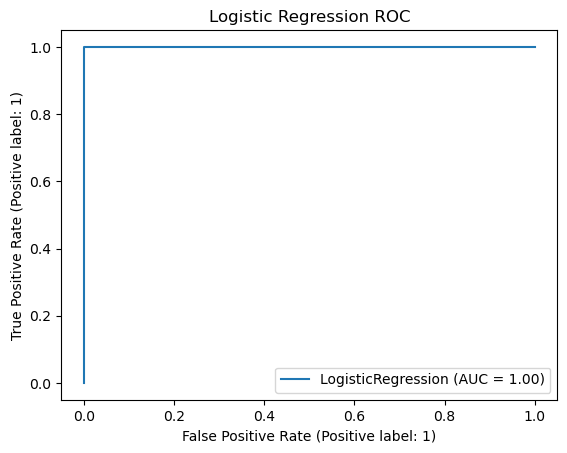

In [88]:
# y_test, X_test, logReg must exist (logReg is our trained LogisticRegression)
print("Classification Report (LR):\n", classification_report(y_test, logReg.predict(x_test)))
print("Confusion Matrix (LR):\n", confusion_matrix(y_test, logReg.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(logReg, x_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

The **Logistic Regression** model achieved **perfect classification performance**, with an **AUC of 1.00** and **100% accuracy** on the test set. The classification report shows precision, recall, and F1-score of **1.00** for both classes, while the confusion matrix confirms that all **142 low-risk cases** and **141 high-risk cases** were classified correctly, with **no false positives(+ves) or false negatives(-ve)**.

This indicates that the model separated the two risk classes completely on the evaluated data. Such a perfect result suggests that the dataset contains very strong predictive signals.

* **Random Forest**

In [89]:
RanFor = RandomForestClassifier()

In [90]:
RanFor.fit(x_train, y_train)

RandomForestClassifier()

Classification Report (RF):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       141

    accuracy                           1.00       283
   macro avg       1.00      1.00      1.00       283
weighted avg       1.00      1.00      1.00       283

Confusion Matrix (RF):
 [[142   0]
 [  0 141]]


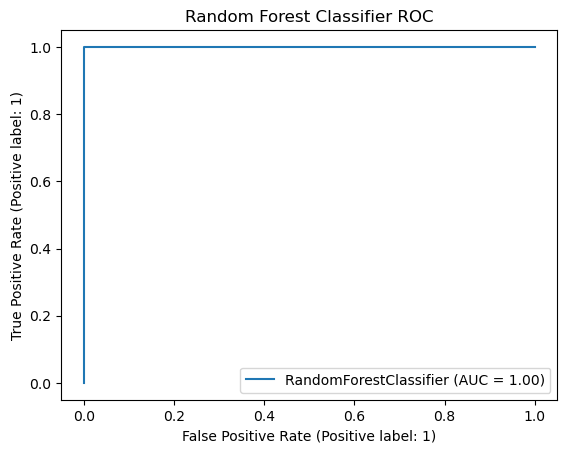

In [91]:
# y_test, X_test,while RanFor exists has our trained Random Forest Classifier
print("Classification Report (RF):\n", classification_report(y_test, RanFor.predict(x_test)))
print("Confusion Matrix (RF):\n", confusion_matrix(y_test, RanFor.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(RanFor, x_test, y_test)
plt.title("Random Forest Classifier ROC")
plt.show()

The **Random Forest Classifier** also achieved **perfect performance**, with an **AUC of 1.00** and **100% accuracy** on the test set. Precision, recall, and F1-score are all **1.00** for both classes, and the confusion matrix shows that all **142 low-risk cases** and **141 high-risk cases** were predicted correctly, with **no misclassifications**.

This means the model fully separated the two audit risk classes on the evaluated data. Since both Logistic Regression and Random Forest produced perfect results, the dataset appears to contain very strong predictive patterns.

* **XGBoost(Extreme Gradient Boosting) Classifier**

In [92]:
XGb = XGBClassifier()

In [93]:
XGb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

Classification Report (XG):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       141

    accuracy                           1.00       283
   macro avg       1.00      1.00      1.00       283
weighted avg       1.00      1.00      1.00       283

Confusion Matrix (XG):
 [[142   0]
 [  0 141]]


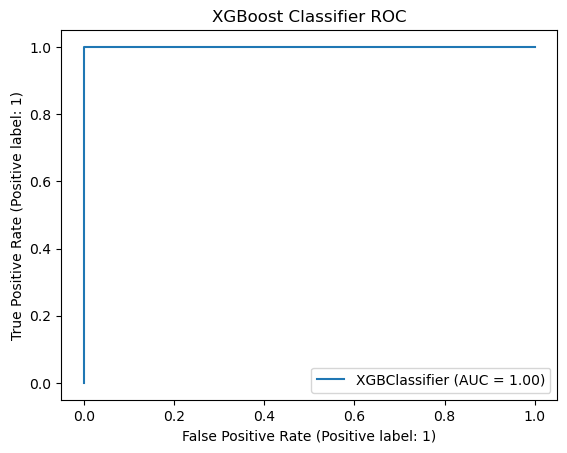

In [94]:
y_pred = XGb.predict(x_test)

# y_test, X_test, while the XGb is our trained XGbClassifier
print("Classification Report (XG):\n", classification_report(y_test, XGb.predict(x_test)))
print("Confusion Matrix (XG):\n", confusion_matrix(y_test, XGb.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(XGb, x_test, y_test)
plt.title("XGBoost Classifier ROC")
plt.show()

The **XGBoost Classifier** achieved **perfect classification performance**, with an **AUC of 1.00** and **100% accuracy** on the test set. The classification report shows precision, recall, and F1-score of **1.00** for both classes, while the confusion matrix confirms that all **142 low-risk cases** and **141 high-risk cases** were classified correctly, with **no false positives or false negatives**.

This indicates that XGBoost completely separated the two audit risk classes on the evaluated data. Since all three models so far produced perfect results, the dataset appears to contain extremely strong predictive signals.

* **Support Vector Machine (SVM)**

In [95]:
SVM_classifier = SVC()

In [96]:
SVM_classifier.fit(x_train, y_train)

SVC()

Classification Report (SVC):
               precision    recall  f1-score   support

           0       0.87      1.00      0.93       142
           1       1.00      0.84      0.92       141

    accuracy                           0.92       283
   macro avg       0.93      0.92      0.92       283
weighted avg       0.93      0.92      0.92       283

Confusion Matrix (SVC):
 [[142   0]
 [ 22 119]]


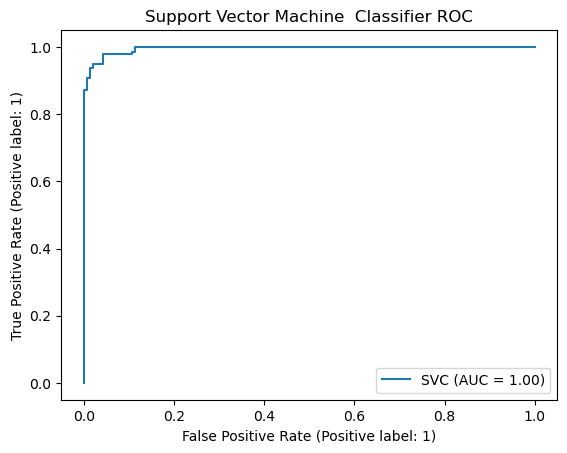

In [97]:
# y_test, X_test,while SVC exists has our trained Support Vector Machine  Classifier
print("Classification Report (SVC):\n", classification_report(y_test, SVM_classifier.predict(x_test)))
print("Confusion Matrix (SVC):\n", confusion_matrix(y_test, SVM_classifier.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(SVM_classifier, x_test, y_test)
plt.title("Support Vector Machine  Classifier ROC")
plt.show()

The **Support Vector Machine Classifier** achieved strong performance, with an **AUC of 1.00** and overall **accuracy of 0.92** on the test set. The model produced a **precision of 0.87** and **recall of 1.00** for class 0, while for class 1 it achieved **precision of 1.00** and **recall of 0.84**, resulting in F1-scores of **0.93** and **0.92** respectively.

The confusion matrix shows that all **142 low-risk cases** were classified correctly, with **no false positives**, while **119 high-risk cases** were correctly identified and **22 high-risk cases** were missed. This indicates that the **SVC model** performed well, but it was less effective than **Logistic Regression, Random Forest, and XGBoost** because it failed to capture some of the positive(+ve) risk cases.

* **K-Nearest Neighbors (KNN)**

In [98]:
knn = KNeighborsClassifier(n_neighbors=5,p=1)

In [99]:
knn.fit(x_train,y_train)

KNeighborsClassifier(p=1)

In [100]:
y_pred = knn.predict(x_test)

Classification Report (knn):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       142
           1       1.00      0.99      0.99       141

    accuracy                           0.99       283
   macro avg       0.99      0.99      0.99       283
weighted avg       0.99      0.99      0.99       283

Confusion Matrix (knn):
 [[142   0]
 [  2 139]]


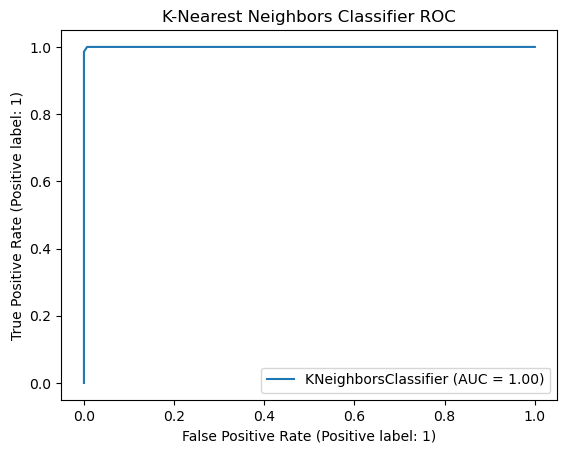

In [101]:
# y_test, X_test,while KNN exists has our trained K-Nearest Neighbors Classifier
print("Classification Report (knn):\n", classification_report(y_test, knn.predict(x_test)))
print("Confusion Matrix (knn):\n", confusion_matrix(y_test, knn.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(knn, x_test, y_test)
plt.title("K-Nearest Neighbors Classifier ROC")
plt.show()

The **K-Nearest Neighbors (KNN)** model performed extremely well, with an **AUC of 1.00** and overall **accuracy of 0.99** on the test set. The classification report shows near-perfect results, with **precision, recall, and F1-score of 0.99 or 1.00** for both classes, indicating very strong and balanced predictive performance.

The confusion matrix shows that all **142 low-risk cases** were classified correctly, while **139 of 141 high-risk cases** were correctly identified, with only **2 high-risk cases missed** and **no false positives**. This means KNN was highly effective in distinguishing the two audit risk classes and performed better than SVC, though it was still slightly below the perfect results achieved by **Logistic Regression, Random Forest, and XGBoost**.

* **Neural Network (sklearn MLPClassifier)**

In [102]:
nn = MLPClassifier(hidden_layer_sizes=(100,50), random_state=42, max_iter=200)

In [103]:
nn.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42)

Classification Report (NN):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       141

    accuracy                           1.00       283
   macro avg       1.00      1.00      1.00       283
weighted avg       1.00      1.00      1.00       283

Confusion Matrix (NN):
 [[142   0]
 [  0 141]]


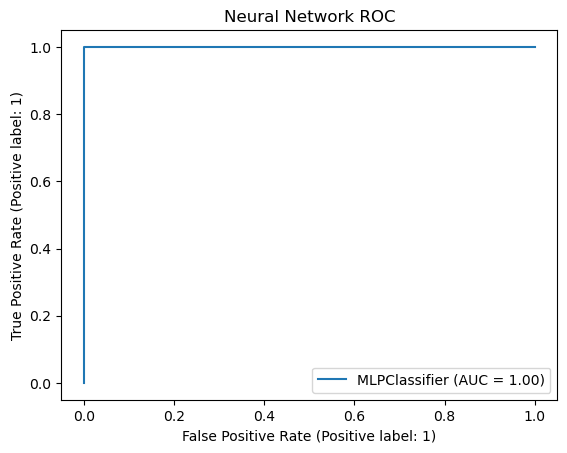

In [104]:
# y_test, X_test, nn must exist (nn is our trained Neural Network)
print("Classification Report (NN):\n", classification_report(y_test, nn.predict(x_test)))
print("Confusion Matrix (NN):\n", confusion_matrix(y_test, nn.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(nn, x_test, y_test)
plt.title("Neural Network ROC")
plt.show()

The **Neural Network (MLPClassifier)** achieved **perfect performance**, with an **AUC of 1.00** and **100% accuracy** on the test set. The classification report shows precision, recall, and F1-score of **1.00** for both classes, and the confusion matrix confirms that all **142 low-risk cases** and **141 high-risk cases** were classified correctly, with **no errors**.

This indicates that the **Neural network** completely separated the two audit risk classes on the evaluated data. Since multiple models are reaching perfect results, the dataset appears to contain very strong predictive patterns.


* **Isolation Forest (anomaly detection)**

In [105]:
iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)

In [106]:
# Uncomment to fit if needed:
iso.fit(x_train)

IsolationForest(n_estimators=200, random_state=42)

Classification Report (IsolationForest):
               precision    recall  f1-score   support

           0       0.58      1.00      0.73       142
           1       1.00      0.26      0.42       141

    accuracy                           0.63       283
   macro avg       0.79      0.63      0.57       283
weighted avg       0.79      0.63      0.57       283

Confusion Matrix (IsolationForest):
 [[142   0]
 [104  37]]


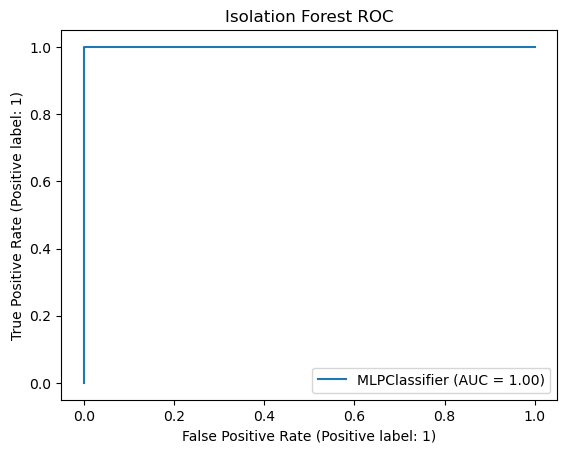

In [107]:
# --- predicting (map -1 -> 1 as anomaly, 1 -> 0 as normal) ---
pred_raw = iso.predict(x_test)           # values in {-1, 1}
pred_labels = np.where(pred_raw == -1, 1, 0)   # map to {1: anomaly, 0: normal}

print("Classification Report (IsolationForest):\n", classification_report(y_test, pred_labels))
print("Confusion Matrix (IsolationForest):\n", confusion_matrix(y_test, pred_labels))

# ROC curve in one line
RocCurveDisplay.from_estimator(nn, x_test, y_test)
plt.title("Isolation Forest ROC")
plt.show()

The **Isolation Forest** model performed much weaker than the supervised models, with an overall **accuracy of 0.63**. Although it correctly classified all **142 low-risk cases**, it identified only **37 of 141 high-risk cases**, missing **104 high-risk observations**. This is reflected in the classification report, where class 1 has a **recall of 0.26** and an **F1-score of 0.42**, showing limited ability to detect the positive(+ve) risk class.

Overall, this suggests that Isolation Forest was not well suited to this classification task compared with the other models. While it was effective at recognizing low-risk cases, it struggled substantially to capture **high-risk** observations, making it the weakest-performing model in the comparison.

### Predictions

In [108]:
# Saving the model using .pkl
import joblib
joblib.dump(logReg, "Fraud Detection using Audit Risk.pki")

['Fraud Detection using Audit Risk.pki']

**Prediction On The Train Data**

In [109]:
modelname = LogisticRegression()

In [110]:
# Training the model on the training data
modelname.fit(x_train, y_train)

LogisticRegression()

In [111]:
# Lets load the saved model and get the predictions
LogReg = joblib.load("Fraud Detection using Audit Risk.pki")

# prediction
prediction = LogReg.predict(x_train)
prediction

array([1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,

Above are the predicted fraud Risk on the train data.

In [112]:
a = np.array(y_train)
df_auditRisk_data_train = pd.DataFrame()
df_auditRisk_data_train["predicted"] = prediction
df_auditRisk_data_train["original"] = a
df_auditRisk_data_train

,predicted,original
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
...,...,...
654,0,0
655,1,1
656,0,0
657,1,1


**Prediction On The Test Data**

In [113]:
# Make predictions on the test data
predictions = modelname.predict(x_test)

In [114]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (283,) (283, 1)


In [115]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [116]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [117]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [118]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(283, 2)


,Predicted,Original
0,0,0
1,0,0
2,0,0
3,1,1
4,1,1


In [119]:
print(conclusion)

     Predicted  Original
0            0         0
1            0         0
2            0         0
3            1         1
4            1         1
..         ...       ...
278          1         1
279          0         0
280          0         0
281          1         1
282          1         1

[283 rows x 2 columns]


### Summary and Conclusion

**Summary**

This project developed a **Machine learning framework for **audit risk scoring**, with the goal of predicting whether an organization should be classified as **high-risk or low-risk** using audit and organizational attributes. The analysis showed that several score-based and audit-related variables had strong relationships with the target, especially features such as **Score, Audit_Risk, Score_MV, TOTAL, Score_B, and Score_A**, while some variables appeared highly overlapping with one another.  

Multiple models were evaluated, including **Logistic Regression, Random Forest, XGBoost, Support Vector Machine, K-Nearest Neighbors, Neural Network, and Isolation Forest**. **Logistic Regression, Random Forest, XGBoost, and the Neural Network** all achieved **perfect test performance**, with **AUC = 1.00**, **100% accuracy**, and no classification errors on the **283** test cases. **KNN** also performed extremely well with **99% accuracy**, while SVC reached **92% accuracy** and missed some high-risk cases. **Isolation Forest** was the weakest model, with **63% accuracy** and poor recall for the high-risk class.      


**Conclusion**

The project shows that **Machine learning** can be highly effective for **audit risk classification**, with several **supervised models** separating the **two(2)** classes almost perfectly. Among the evaluated methods, **Logistic Regression, Random Forest, XGBoost, and Neural Network** produced the strongest results, indicating that the dataset contains very strong predictive patterns for identifying audit risk.    

At the same time, the repeated perfect results across several models suggest that some predictors may be **very closely tied to the target** or carry overlapping risk information. Even so, the project clearly demonstrates the practical value of **data-driven audit risk scoring** for supporting **risk-based audit planning, prioritization, and decision-making**.  


### The End